=== Paramètres Physiques Calculés ===
lambda = 1.0000  |  lambda_eff = 1.0125  |  Ca = 0.0000
prefactor (eq. 1.78) = -0.3093  |  elastic_coef = -0.0000

=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===
Epoch     1 | Loss Globale: 5.6395e-01 | Loss Phys: 3.3129e-02 | Loss Data: 5.2037e-01
Epoch    10 | Loss Globale: 2.1915e-05 | Loss Phys: 1.9871e-05 | Loss Data: 2.0223e-06
Epoch    20 | Loss Globale: 8.2484e-06 | Loss Phys: 7.5110e-06 | Loss Data: 7.3686e-07
>>> Génération et affichage des graphiques pour l'epoch 20...


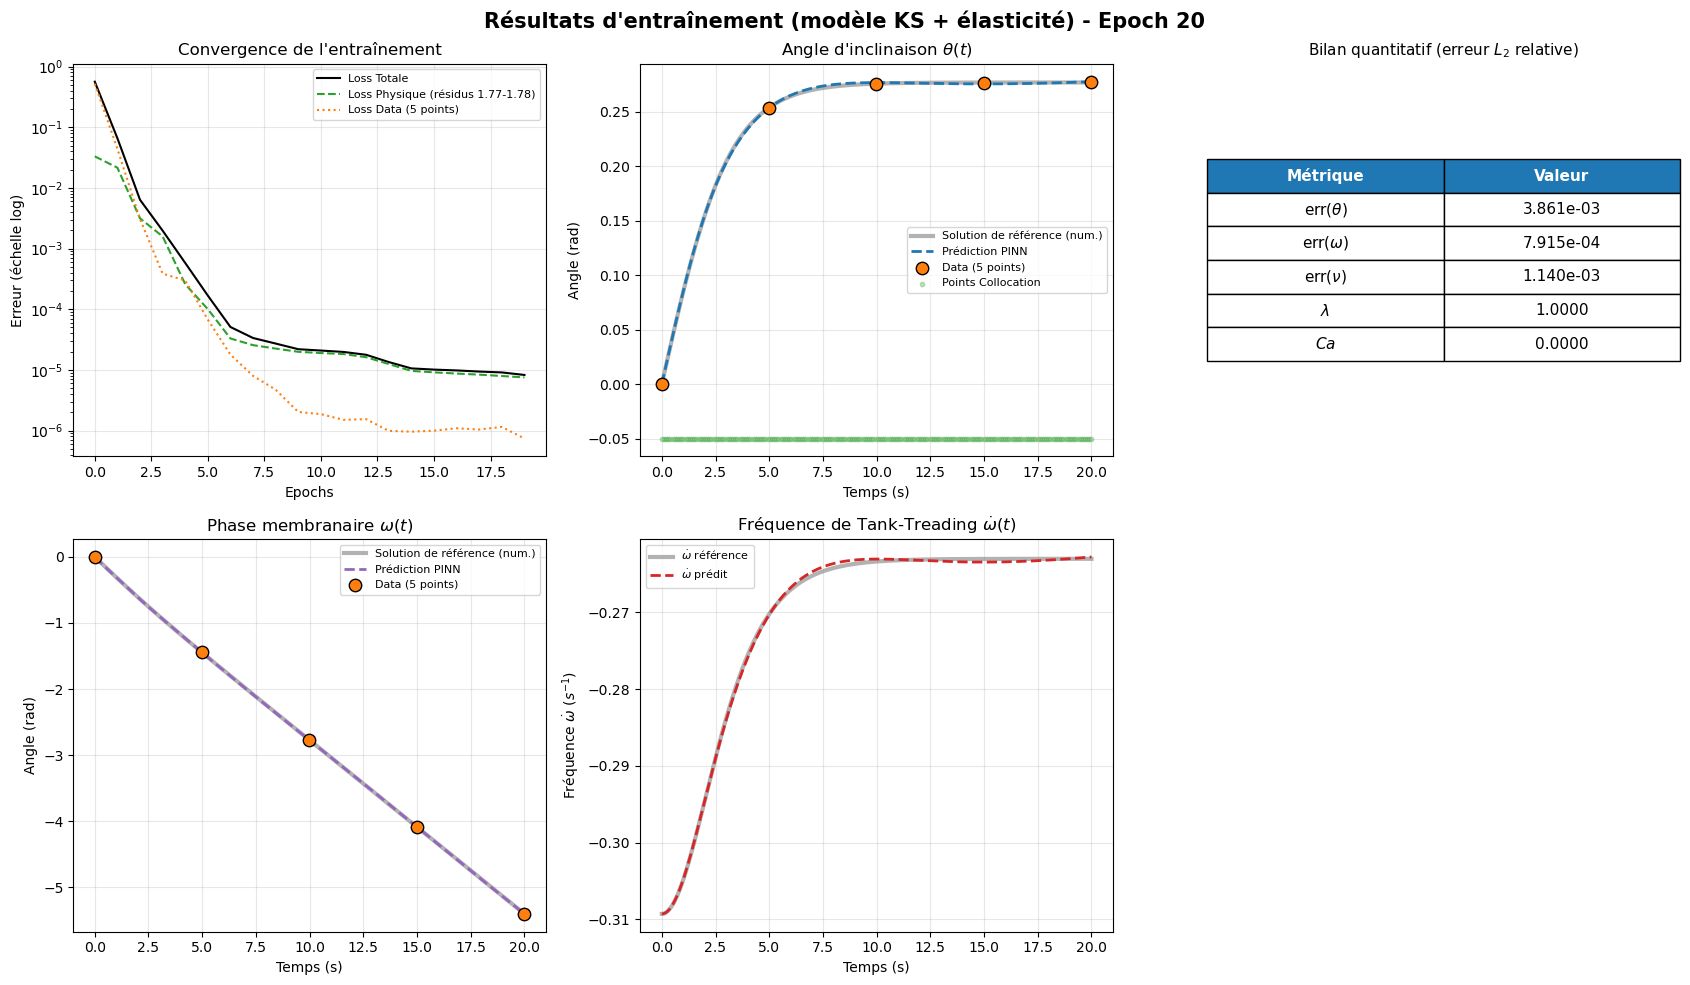

Epoch    30 | Loss Globale: 3.9555e-06 | Loss Phys: 3.8962e-06 | Loss Data: 5.8405e-08
Epoch    40 | Loss Globale: 2.0226e-06 | Loss Phys: 2.0145e-06 | Loss Data: 7.2519e-09
Epoch    50 | Loss Globale: 6.8810e-07 | Loss Phys: 6.6429e-07 | Loss Data: 2.3677e-08
>>> Génération et affichage des graphiques pour l'epoch 50...


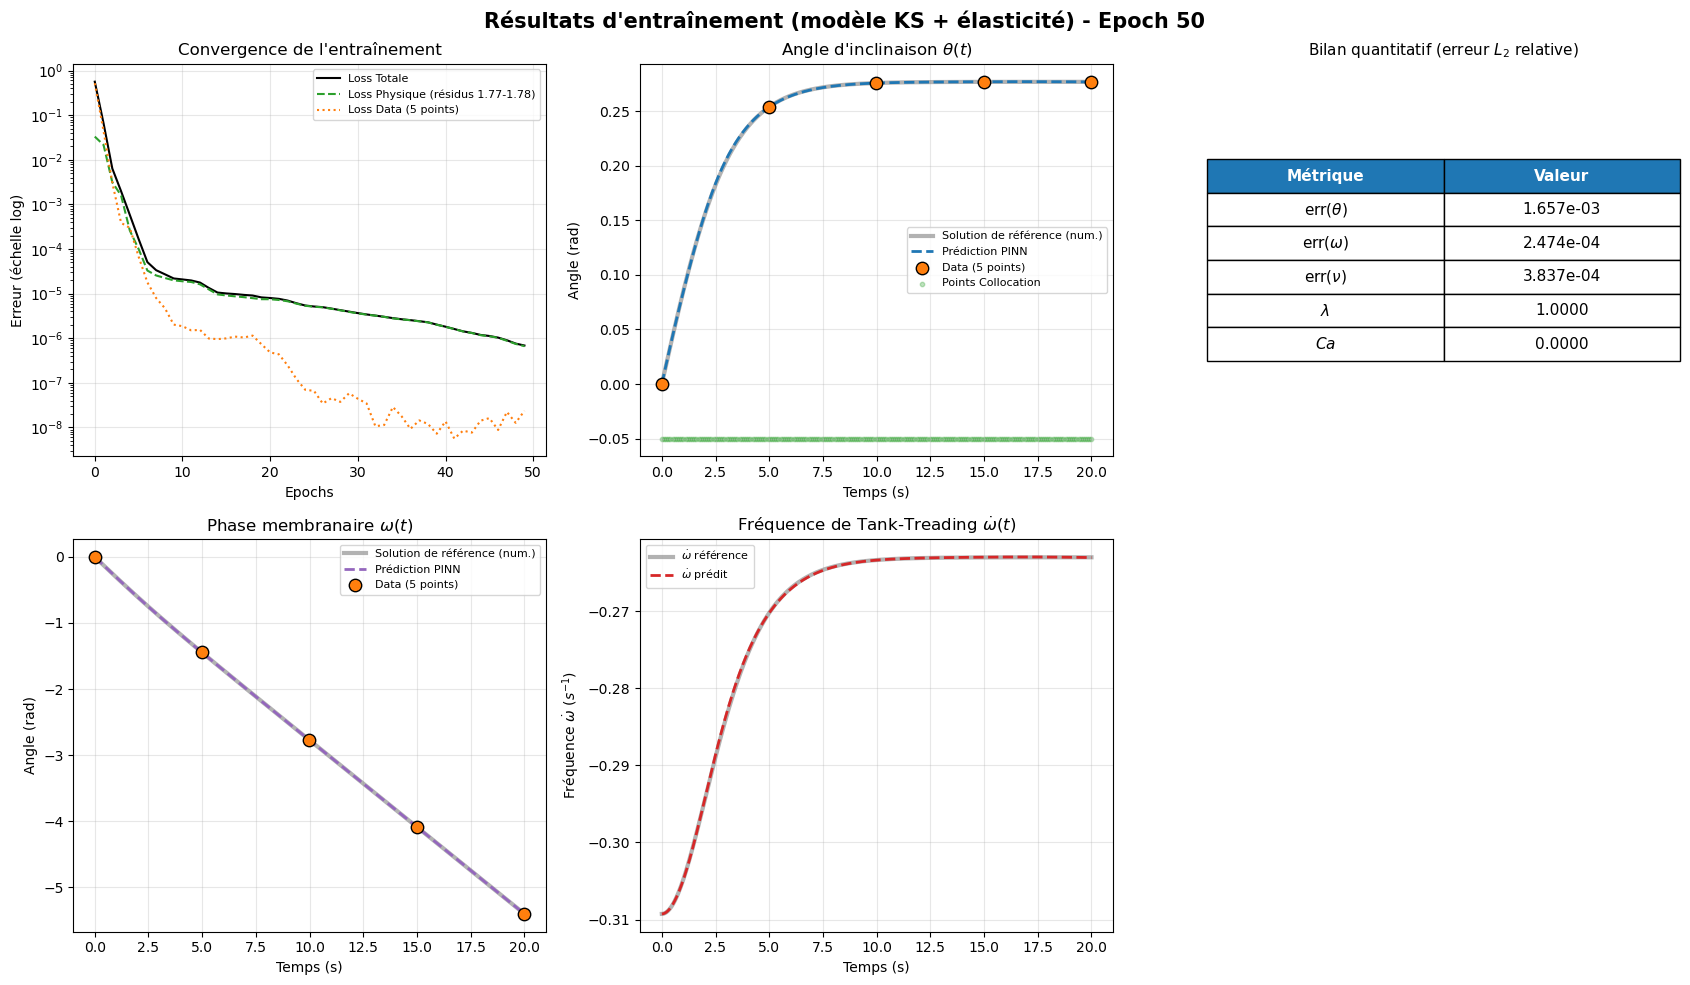

Epoch    60 | Loss Globale: 2.7552e-07 | Loss Phys: 2.5642e-07 | Loss Data: 1.9042e-08
Epoch    70 | Loss Globale: 2.2900e-07 | Loss Phys: 2.0694e-07 | Loss Data: 2.2022e-08
Epoch    80 | Loss Globale: 2.1793e-07 | Loss Phys: 1.9315e-07 | Loss Data: 2.4581e-08
Epoch    90 | Loss Globale: 2.1236e-07 | Loss Phys: 1.9123e-07 | Loss Data: 2.1022e-08
Epoch   100 | Loss Globale: 2.1129e-07 | Loss Phys: 1.9093e-07 | Loss Data: 2.0357e-08
>>> Génération et affichage des graphiques pour l'epoch 100...


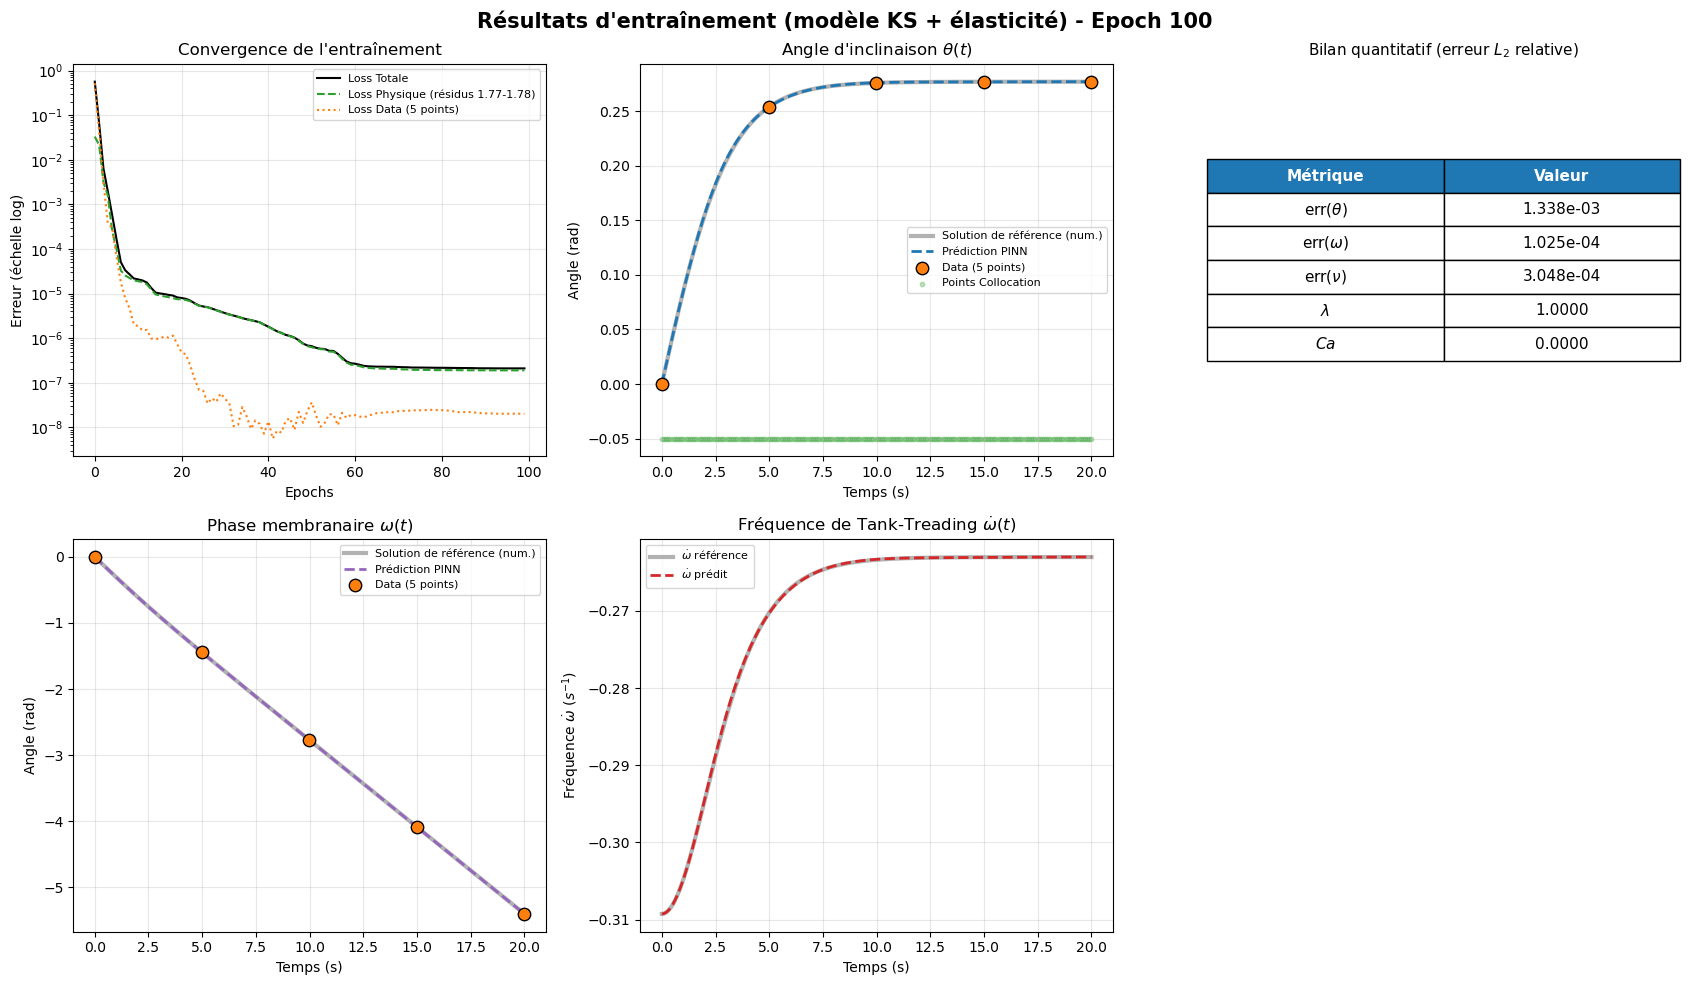

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
Test1bis_mu1.2_lambda1.0            | err_theta = 1.338e-03 | err_omega = 1.025e-04 | err_nu = 3.048e-04


(0.0013384472634297168, 0.0001025036956540079, 0.0003048324218418069)

In [2]:
"""
================================================================================
 PINN — Mouvement d'un globule rouge en cisaillement : modèle de Keller-Skalak
 ÉTENDU avec l'élasticité de cisaillement de la membrane (Abkarian et al. 2007)
 Réf. : Abkarian 2016 (HDR), section 1.3.4, équations (1.77)-(1.78)
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

torch.set_default_dtype(torch.float32)
torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (déplacées ICI, tout en haut, une seule fois)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul (ex: ref oscille autour de 0), on utilise
    l'erreur L2 absolue normalisée par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, filename="metriques_tests.txt"):
    """Calcule les 3 erreurs L2 relatives et les ajoute au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.2
mu_app = 1.2
theta0_val = 0.0

G = 0.0
mu_m = 0.2
Omega_over_V = 7.48e-2
omega0_val = 0.0


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

lam = mu_app / mu
lam_eff = lam * (1 + (mu_m / mu_app) * Omega_over_V)
Ca = G / (mu * kappa)

geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

prefactor = -f3 / (f2 - lam_eff * f1)
elastic_coef = (f1 * G * Omega_over_V) / (2 * f3 * mu * kappa)

print("=== Paramètres Physiques Calculés ===")
print(f"lambda = {lam:.4f}  |  lambda_eff = {lam_eff:.4f}  |  Ca = {Ca:.4f}")
print(f"prefactor (eq. 1.78) = {prefactor:.4f}  |  elastic_coef = {elastic_coef:.4f}")


# =====================================================================
# 2. SOLUTION NUMÉRIQUE DE RÉFÉRENCE + SÉLECTION DES POINTS DATA (5 POINTS)
# =====================================================================
def rhs_reference(t, state):
    theta, omega = state
    domega_dt = kappa * prefactor * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
    dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
    return [dtheta_dt, domega_dt]


t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)

sol_ref = solve_ivp(
    rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
    t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-9, atol=1e-11,
)
theta_ref_np = sol_ref.y[0].reshape(-1, 1)
omega_ref_np = sol_ref.y[1].reshape(-1, 1)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
theta_ref = torch.tensor(theta_ref_np, dtype=torch.float32)
omega_ref = torch.tensor(omega_ref_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
theta_data = theta_ref[data_idx].detach()
omega_data = omega_ref[data_idx].detach()

t_ic = torch.tensor([[0.0]], requires_grad=True)


# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


model = FCN(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    tolerance_grad=1e-7, tolerance_change=1e-9,
    history_size=100, line_search_fn="strong_wolfe",
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, loss_data_hist, epoch_hist = [], [], [], []


# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille passée de 2x2 à 2x3 pour laisser une case au tableau de métriques)
# =====================================================================
def nu_from_theta_omega(theta_arr, omega_arr):
    return kappa * prefactor * (np.cos(2 * theta_arr) - elastic_coef * np.sin(2 * omega_arr))


def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn, omega_pinn = current_model(t_exact)
        theta_pinn = theta_pinn.numpy()
        omega_pinn = omega_pinn.numpy()

    nu_pinn = nu_from_theta_omega(theta_pinn, omega_pinn)
    nu_ref = nu_from_theta_omega(theta_ref_np, omega_ref_np)

    # --- Métriques L2 relatives à l'epoch courante (affichage seulement,
    #     pas d'écriture dans le fichier récapitulatif ici -> ça, c'est
    #     réservé à la métrique finale, section 6, pour ne pas polluer
    #     metriques_tests.txt avec des valeurs intermédiaires) ---
    err_theta = l2_relative_error(theta_pinn, theta_ref_np)
    err_omega = l2_relative_error(omega_pinn, omega_ref_np)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    fig = plt.figure(figsize=(17, 10))
    fig.suptitle(f"Résultats d'entraînement (modèle KS + élasticité) - Epoch {current_epoch}",
                 fontsize=15, fontweight="bold")

    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique (résidus 1.77-1.78)",
              color="tab:green", linestyle="--")
    ax1.plot(epoch_hist, loss_data_hist, label="Loss Data (5 points)",
              color="tab:orange", linestyle=":")
    ax1.set_yscale("log")
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)

    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(t_exact_np, theta_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), theta_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    colloc_y = np.min(theta_ref_np) - 0.05
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")
    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    # --- Tableau des métriques, case libre (position 3, haut-droite) ---
    ax3 = plt.subplot(2, 3, 3)
    ax3.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\omega$)", f"{err_omega:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$\lambda$",     f"{lam:.4f}"],
        [r"$Ca$",          f"{Ca:.4f}"],
    ]
    tbl = ax3.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.5, 0.5],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax3.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(t_exact_np, omega_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax4.plot(t_exact_np, omega_pinn, color="tab:purple", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax4.scatter(t_data.numpy(), omega_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    ax4.set_title(r"Phase membranaire $\omega(t)$")
    ax4.set_xlabel("Temps (s)")
    ax4.set_ylabel("Angle (rad)")
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)

    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(t_exact_np, nu_ref, color="grey", linewidth=3, alpha=0.6, label=r"$\dot\omega$ référence")
    ax5.plot(t_exact_np, nu_pinn, color="tab:red", linestyle="--", linewidth=2, label=r"$\dot\omega$ prédit")
    ax5.set_title(r"Fréquence de Tank-Treading $\dot\omega(t)$")
    ax5.set_xlabel("Temps (s)")
    ax5.set_ylabel(r"Fréquence $\dot\omega$ ($s^{-1}$)")
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=8)

    # ax6 (position 6) laissée vide -- grille 2x3 complète sans surcharge

    plt.tight_layout()
    plt.show()          # <-- reste bien à l'intérieur de plot_current_state
    current_model.train()  # <-- reste bien à l'intérieur de plot_current_state


# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [20, 50, 100]

print("\n=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===")

for epoch in range(n_epochs):
    loss_tracker = {"total": 0.0, "phys": 0.0, "data": 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred),
            create_graph=True,
        )[0]
        domega_dt = torch.autograd.grad(
            omega_pred, t_physics, grad_outputs=torch.ones_like(omega_pred),
            create_graph=True,
        )[0]

        rhs_omega = kappa * prefactor * (
            torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred)
        )
        residu_omega = domega_dt - rhs_omega

        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta

        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0
        loss.backward()

        loss_tracker["total"] = loss.item()
        loss_tracker["phys"] = loss_physics.item()
        loss_tracker["data"] = loss_data.item()
        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker["total"])
    loss_phys_hist.append(loss_tracker["phys"])
    loss_data_hist.append(loss_tracker["data"])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} "
              f"| Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final, omega_final = model(t_exact)
    theta_final = theta_final.numpy()
    omega_final = omega_final.numpy()
model.train()

nu_final = nu_from_theta_omega(theta_final, omega_final)
nu_ref_final = nu_from_theta_omega(theta_ref_np, omega_ref_np)

print_and_save_metrics(
    "Test1bis_mu1.2_lambda1.0",
    theta_final, theta_ref_np,
    omega_final, omega_ref_np,
    nu_final, nu_ref_final,
)

=== Paramètres Physiques Calculés ===
lambda = 1.0000  |  lambda_eff = 1.0125  |  Ca = 0.4167
prefactor (eq. 1.78) = -0.3093  |  elastic_coef = -0.0300

=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===
Epoch     1 | Loss Globale: 5.5893e-01 | Loss Phys: 3.3711e-02 | Loss Data: 5.1514e-01
Epoch    10 | Loss Globale: 8.1491e-05 | Loss Phys: 6.0729e-05 | Loss Data: 2.0740e-05
Epoch    20 | Loss Globale: 2.3929e-05 | Loss Phys: 2.2516e-05 | Loss Data: 1.4081e-06
>>> Génération et affichage des graphiques pour l'epoch 20...


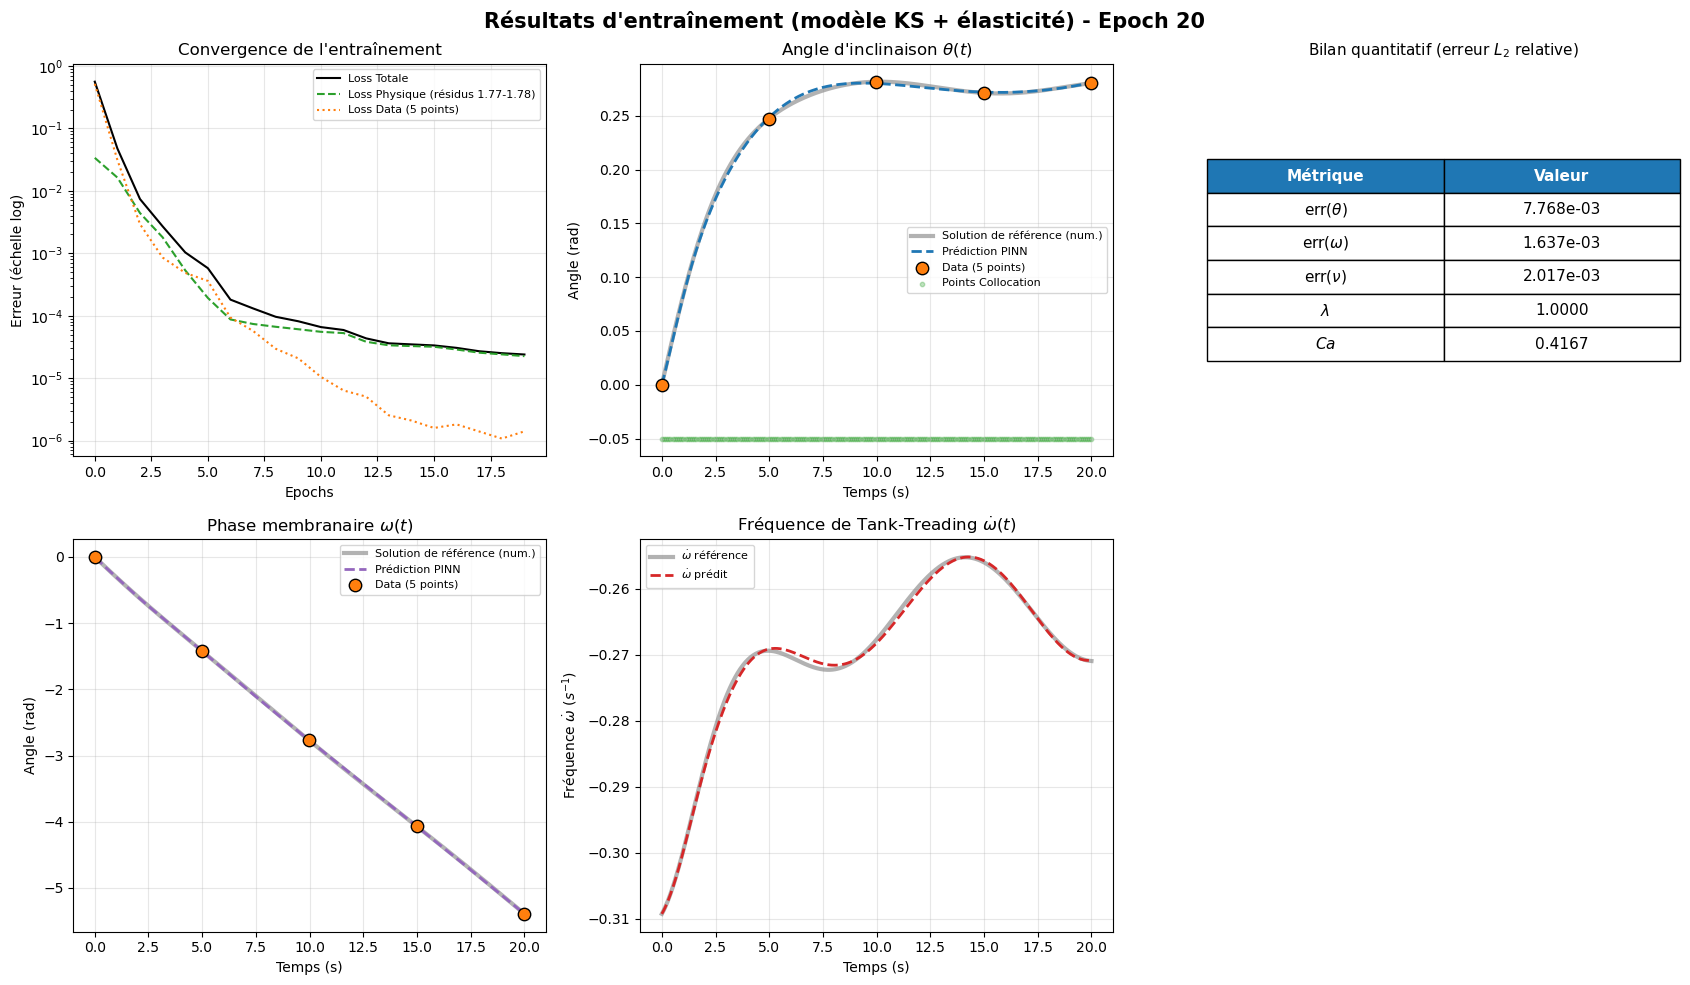

Epoch    30 | Loss Globale: 1.5610e-05 | Loss Phys: 1.5373e-05 | Loss Data: 2.3329e-07
Epoch    40 | Loss Globale: 7.5325e-06 | Loss Phys: 6.7619e-06 | Loss Data: 7.6598e-07
Epoch    50 | Loss Globale: 3.6861e-06 | Loss Phys: 3.3970e-06 | Loss Data: 2.8877e-07
>>> Génération et affichage des graphiques pour l'epoch 50...


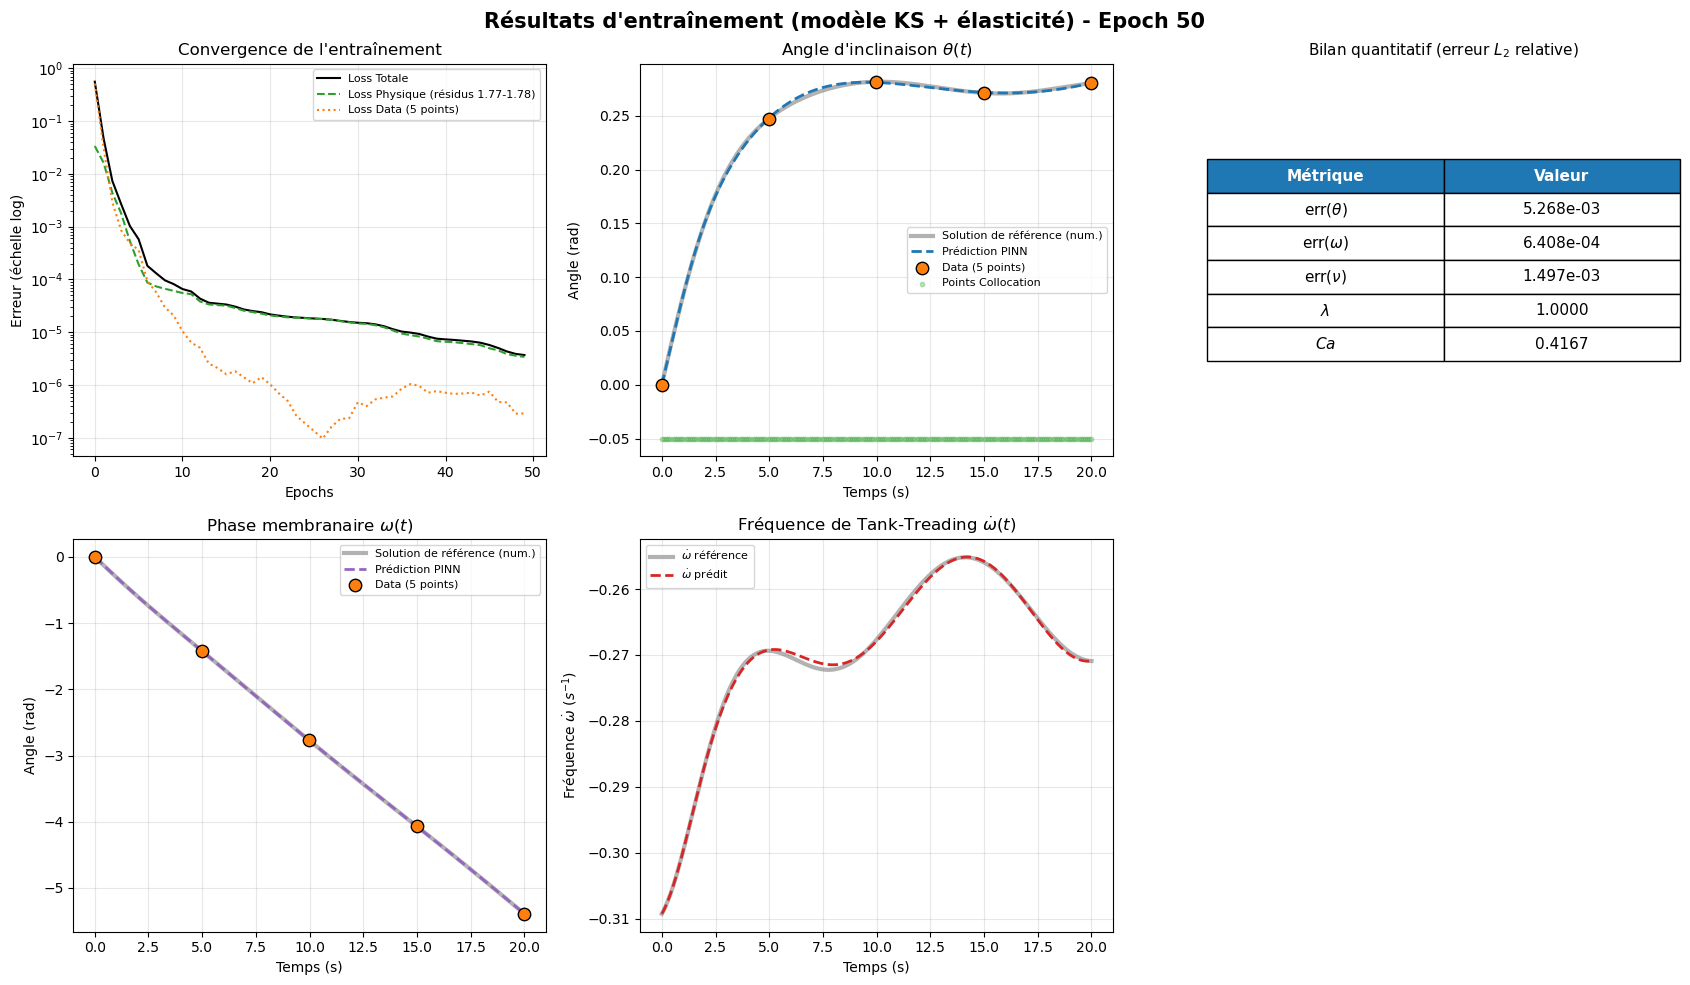

Epoch    60 | Loss Globale: 2.8655e-06 | Loss Phys: 2.7559e-06 | Loss Data: 1.0956e-07
Epoch    70 | Loss Globale: 2.4346e-06 | Loss Phys: 2.3254e-06 | Loss Data: 1.0910e-07
Epoch    80 | Loss Globale: 1.9945e-06 | Loss Phys: 1.7970e-06 | Loss Data: 1.9700e-07
Epoch    90 | Loss Globale: 1.9825e-06 | Loss Phys: 1.7846e-06 | Loss Data: 1.9789e-07
Epoch   100 | Loss Globale: 1.9793e-06 | Loss Phys: 1.7784e-06 | Loss Data: 2.0095e-07
>>> Génération et affichage des graphiques pour l'epoch 100...


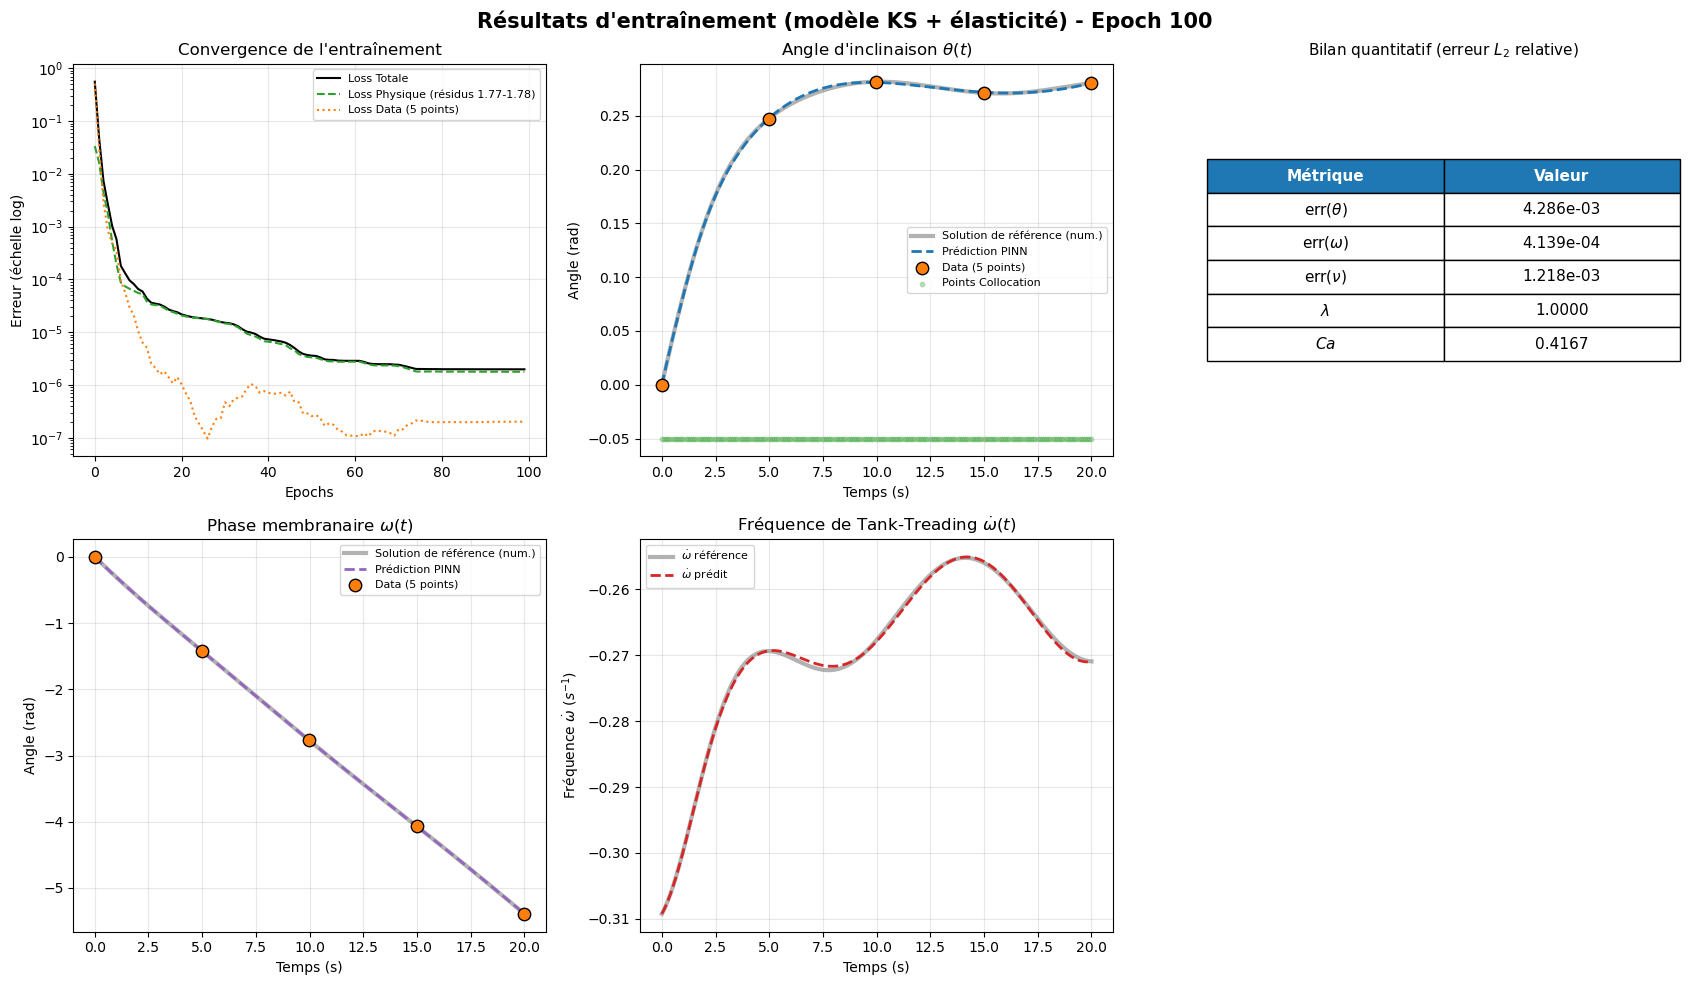

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
Test1bis_mu1.2_lambda1.0            | err_theta = 4.286e-03 | err_omega = 4.139e-04 | err_nu = 1.218e-03


(0.004285502912692986, 0.0004138896445455704, 0.0012179673810637883)

In [3]:
"""
================================================================================
 PINN — Mouvement d'un globule rouge en cisaillement : modèle de Keller-Skalak
 ÉTENDU avec l'élasticité de cisaillement de la membrane (Abkarian et al. 2007)
 Réf. : Abkarian 2016 (HDR), section 1.3.4, équations (1.77)-(1.78)
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

torch.set_default_dtype(torch.float32)
torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (déplacées ICI, tout en haut, une seule fois)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul (ex: ref oscille autour de 0), on utilise
    l'erreur L2 absolue normalisée par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, filename="metriques_tests.txt"):
    """Calcule les 3 erreurs L2 relatives et les ajoute au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.2
mu_app = 1.2
theta0_val = 0.0

G = 0.5
mu_m = 0.2
Omega_over_V = 7.48e-2
omega0_val = 0.0


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

lam = mu_app / mu
lam_eff = lam * (1 + (mu_m / mu_app) * Omega_over_V)
Ca = G / (mu * kappa)

geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

prefactor = -f3 / (f2 - lam_eff * f1)
elastic_coef = (f1 * G * Omega_over_V) / (2 * f3 * mu * kappa)

print("=== Paramètres Physiques Calculés ===")
print(f"lambda = {lam:.4f}  |  lambda_eff = {lam_eff:.4f}  |  Ca = {Ca:.4f}")
print(f"prefactor (eq. 1.78) = {prefactor:.4f}  |  elastic_coef = {elastic_coef:.4f}")


# =====================================================================
# 2. SOLUTION NUMÉRIQUE DE RÉFÉRENCE + SÉLECTION DES POINTS DATA (5 POINTS)
# =====================================================================
def rhs_reference(t, state):
    theta, omega = state
    domega_dt = kappa * prefactor * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
    dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
    return [dtheta_dt, domega_dt]


t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)

sol_ref = solve_ivp(
    rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
    t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-9, atol=1e-11,
)
theta_ref_np = sol_ref.y[0].reshape(-1, 1)
omega_ref_np = sol_ref.y[1].reshape(-1, 1)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
theta_ref = torch.tensor(theta_ref_np, dtype=torch.float32)
omega_ref = torch.tensor(omega_ref_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
theta_data = theta_ref[data_idx].detach()
omega_data = omega_ref[data_idx].detach()

t_ic = torch.tensor([[0.0]], requires_grad=True)


# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


model = FCN(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    tolerance_grad=1e-7, tolerance_change=1e-9,
    history_size=100, line_search_fn="strong_wolfe",
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, loss_data_hist, epoch_hist = [], [], [], []


# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille passée de 2x2 à 2x3 pour laisser une case au tableau de métriques)
# =====================================================================
def nu_from_theta_omega(theta_arr, omega_arr):
    return kappa * prefactor * (np.cos(2 * theta_arr) - elastic_coef * np.sin(2 * omega_arr))


def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn, omega_pinn = current_model(t_exact)
        theta_pinn = theta_pinn.numpy()
        omega_pinn = omega_pinn.numpy()

    nu_pinn = nu_from_theta_omega(theta_pinn, omega_pinn)
    nu_ref = nu_from_theta_omega(theta_ref_np, omega_ref_np)

    # --- Métriques L2 relatives à l'epoch courante (affichage seulement,
    #     pas d'écriture dans le fichier récapitulatif ici -> ça, c'est
    #     réservé à la métrique finale, section 6, pour ne pas polluer
    #     metriques_tests.txt avec des valeurs intermédiaires) ---
    err_theta = l2_relative_error(theta_pinn, theta_ref_np)
    err_omega = l2_relative_error(omega_pinn, omega_ref_np)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    fig = plt.figure(figsize=(17, 10))
    fig.suptitle(f"Résultats d'entraînement (modèle KS + élasticité) - Epoch {current_epoch}",
                 fontsize=15, fontweight="bold")

    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique (résidus 1.77-1.78)",
              color="tab:green", linestyle="--")
    ax1.plot(epoch_hist, loss_data_hist, label="Loss Data (5 points)",
              color="tab:orange", linestyle=":")
    ax1.set_yscale("log")
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)

    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(t_exact_np, theta_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), theta_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    colloc_y = np.min(theta_ref_np) - 0.05
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")
    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    # --- Tableau des métriques, case libre (position 3, haut-droite) ---
    ax3 = plt.subplot(2, 3, 3)
    ax3.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\omega$)", f"{err_omega:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$\lambda$",     f"{lam:.4f}"],
        [r"$Ca$",          f"{Ca:.4f}"],
    ]
    tbl = ax3.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.5, 0.5],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax3.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(t_exact_np, omega_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax4.plot(t_exact_np, omega_pinn, color="tab:purple", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax4.scatter(t_data.numpy(), omega_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    ax4.set_title(r"Phase membranaire $\omega(t)$")
    ax4.set_xlabel("Temps (s)")
    ax4.set_ylabel("Angle (rad)")
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)

    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(t_exact_np, nu_ref, color="grey", linewidth=3, alpha=0.6, label=r"$\dot\omega$ référence")
    ax5.plot(t_exact_np, nu_pinn, color="tab:red", linestyle="--", linewidth=2, label=r"$\dot\omega$ prédit")
    ax5.set_title(r"Fréquence de Tank-Treading $\dot\omega(t)$")
    ax5.set_xlabel("Temps (s)")
    ax5.set_ylabel(r"Fréquence $\dot\omega$ ($s^{-1}$)")
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=8)

    # ax6 (position 6) laissée vide -- grille 2x3 complète sans surcharge

    plt.tight_layout()
    plt.show()          # <-- reste bien à l'intérieur de plot_current_state
    current_model.train()  # <-- reste bien à l'intérieur de plot_current_state


# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [20, 50, 100]

print("\n=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===")

for epoch in range(n_epochs):
    loss_tracker = {"total": 0.0, "phys": 0.0, "data": 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred),
            create_graph=True,
        )[0]
        domega_dt = torch.autograd.grad(
            omega_pred, t_physics, grad_outputs=torch.ones_like(omega_pred),
            create_graph=True,
        )[0]

        rhs_omega = kappa * prefactor * (
            torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred)
        )
        residu_omega = domega_dt - rhs_omega

        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta

        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0
        loss.backward()

        loss_tracker["total"] = loss.item()
        loss_tracker["phys"] = loss_physics.item()
        loss_tracker["data"] = loss_data.item()
        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker["total"])
    loss_phys_hist.append(loss_tracker["phys"])
    loss_data_hist.append(loss_tracker["data"])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} "
              f"| Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final, omega_final = model(t_exact)
    theta_final = theta_final.numpy()
    omega_final = omega_final.numpy()
model.train()

nu_final = nu_from_theta_omega(theta_final, omega_final)
nu_ref_final = nu_from_theta_omega(theta_ref_np, omega_ref_np)

print_and_save_metrics(
    "Test1bis_mu1.2_lambda1.0",
    theta_final, theta_ref_np,
    omega_final, omega_ref_np,
    nu_final, nu_ref_final,
)

=== Paramètres Physiques Calculés ===
lambda = 5.0000  |  lambda_eff = 5.0150  |  Ca = 0.5000
prefactor (eq. 1.78) = -0.0914  |  elastic_coef = -0.0360

=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===
Epoch     1 | Loss Globale: 1.9647e-01 | Loss Phys: 9.7441e-02 | Loss Data: 7.9498e-02
Epoch    10 | Loss Globale: 6.1518e-03 | Loss Phys: 4.8695e-03 | Loss Data: 1.2814e-03
Epoch    20 | Loss Globale: 2.1417e-04 | Loss Phys: 2.1203e-04 | Loss Data: 2.1377e-06
>>> Génération et affichage des graphiques pour l'epoch 20...


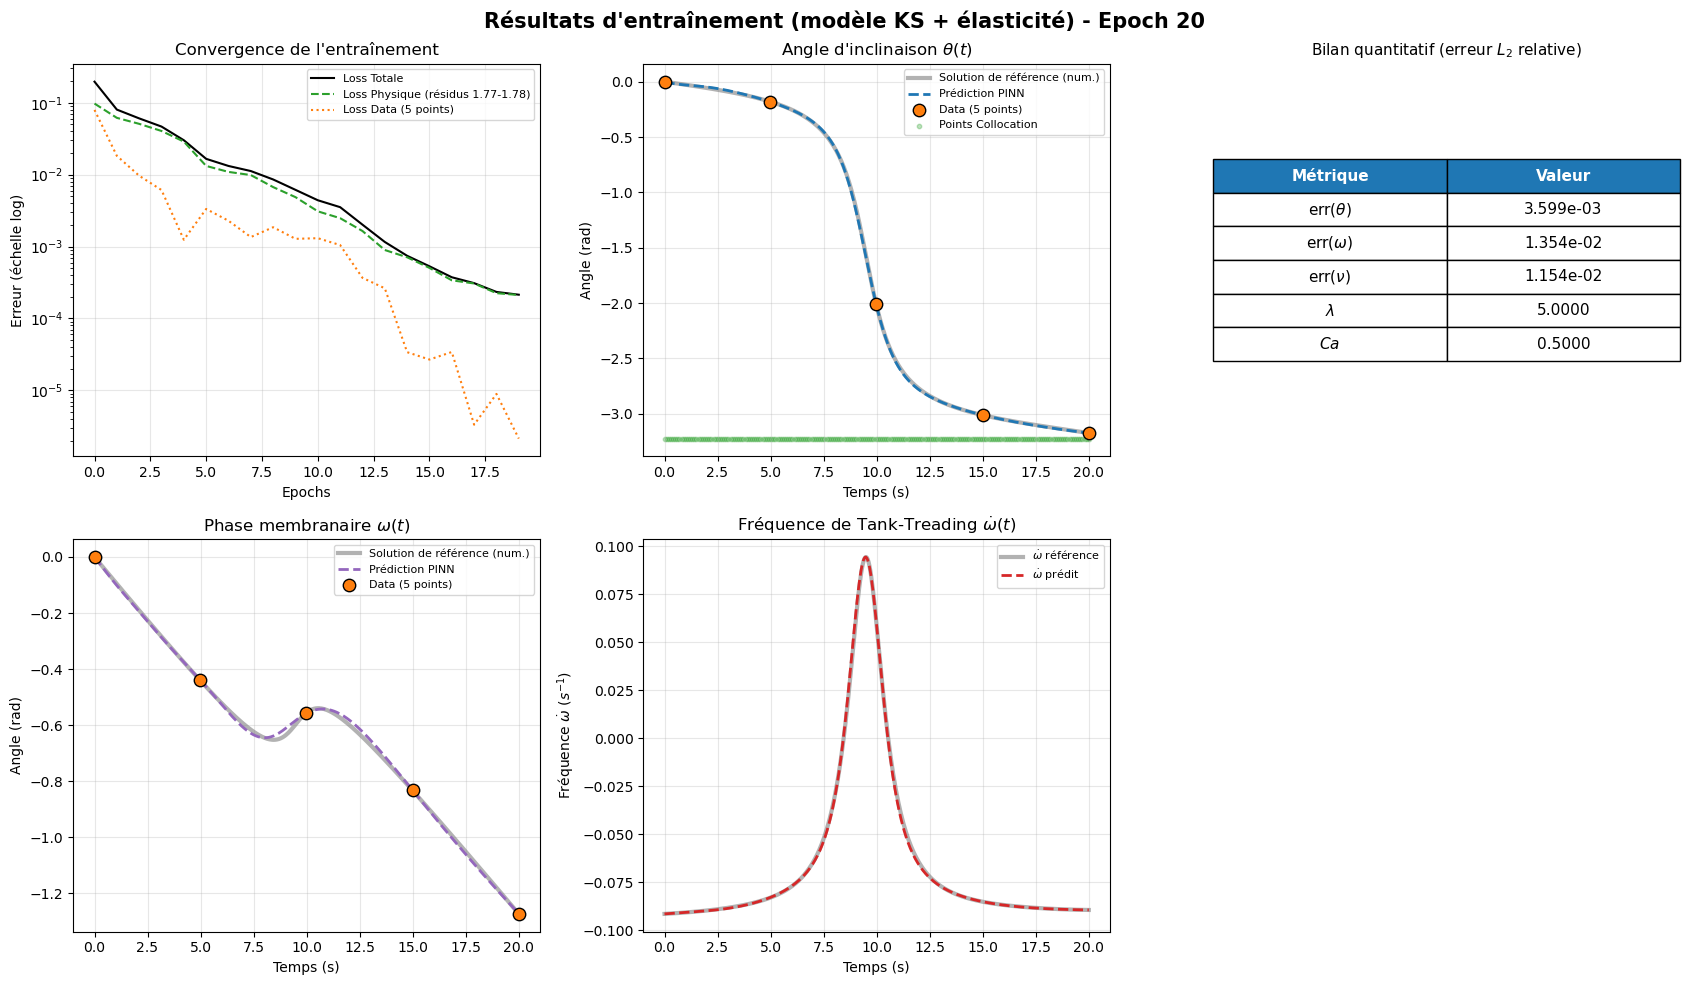

Epoch    30 | Loss Globale: 4.5603e-05 | Loss Phys: 4.5150e-05 | Loss Data: 4.4596e-07
Epoch    40 | Loss Globale: 2.2448e-05 | Loss Phys: 2.2287e-05 | Loss Data: 1.5829e-07
Epoch    50 | Loss Globale: 9.0709e-06 | Loss Phys: 8.7281e-06 | Loss Data: 3.4188e-07
>>> Génération et affichage des graphiques pour l'epoch 50...


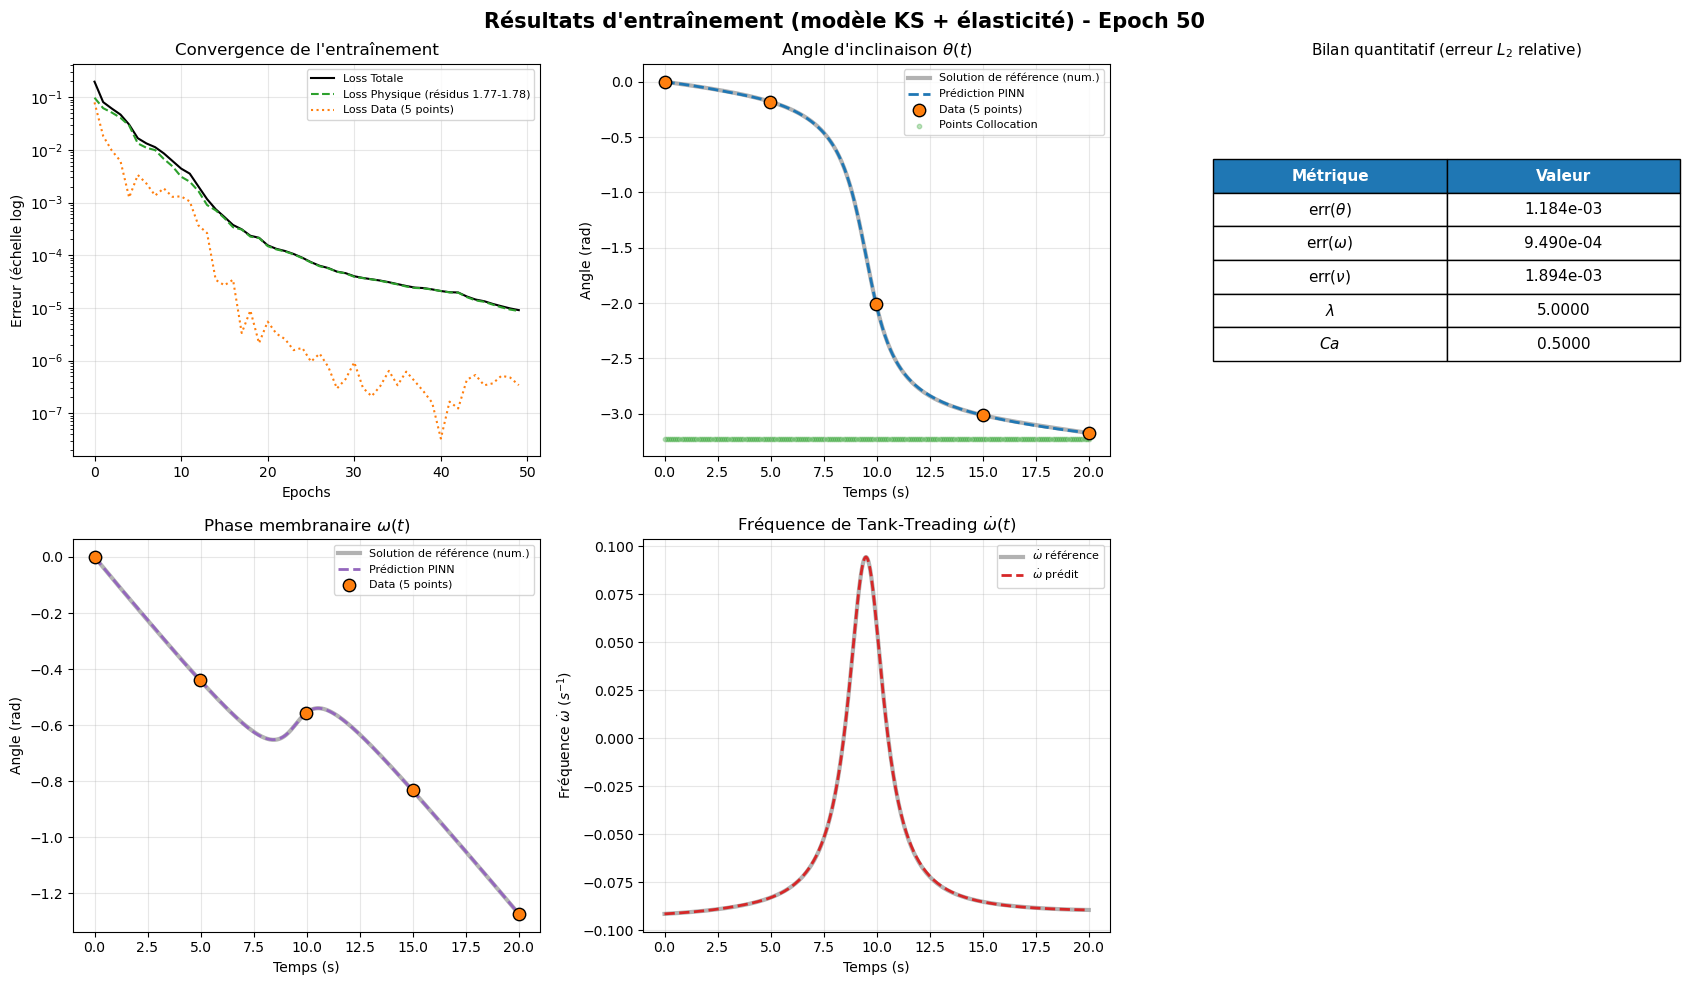

Epoch    60 | Loss Globale: 5.2888e-06 | Loss Phys: 5.2623e-06 | Loss Data: 2.6031e-08
Epoch    70 | Loss Globale: 2.4149e-06 | Loss Phys: 2.4098e-06 | Loss Data: 4.9300e-09
Epoch    80 | Loss Globale: 2.0723e-06 | Loss Phys: 2.0468e-06 | Loss Data: 2.5517e-08
Epoch    90 | Loss Globale: 2.0130e-06 | Loss Phys: 1.9827e-06 | Loss Data: 3.0292e-08
Epoch   100 | Loss Globale: 1.9680e-06 | Loss Phys: 1.9387e-06 | Loss Data: 2.9377e-08
>>> Génération et affichage des graphiques pour l'epoch 100...


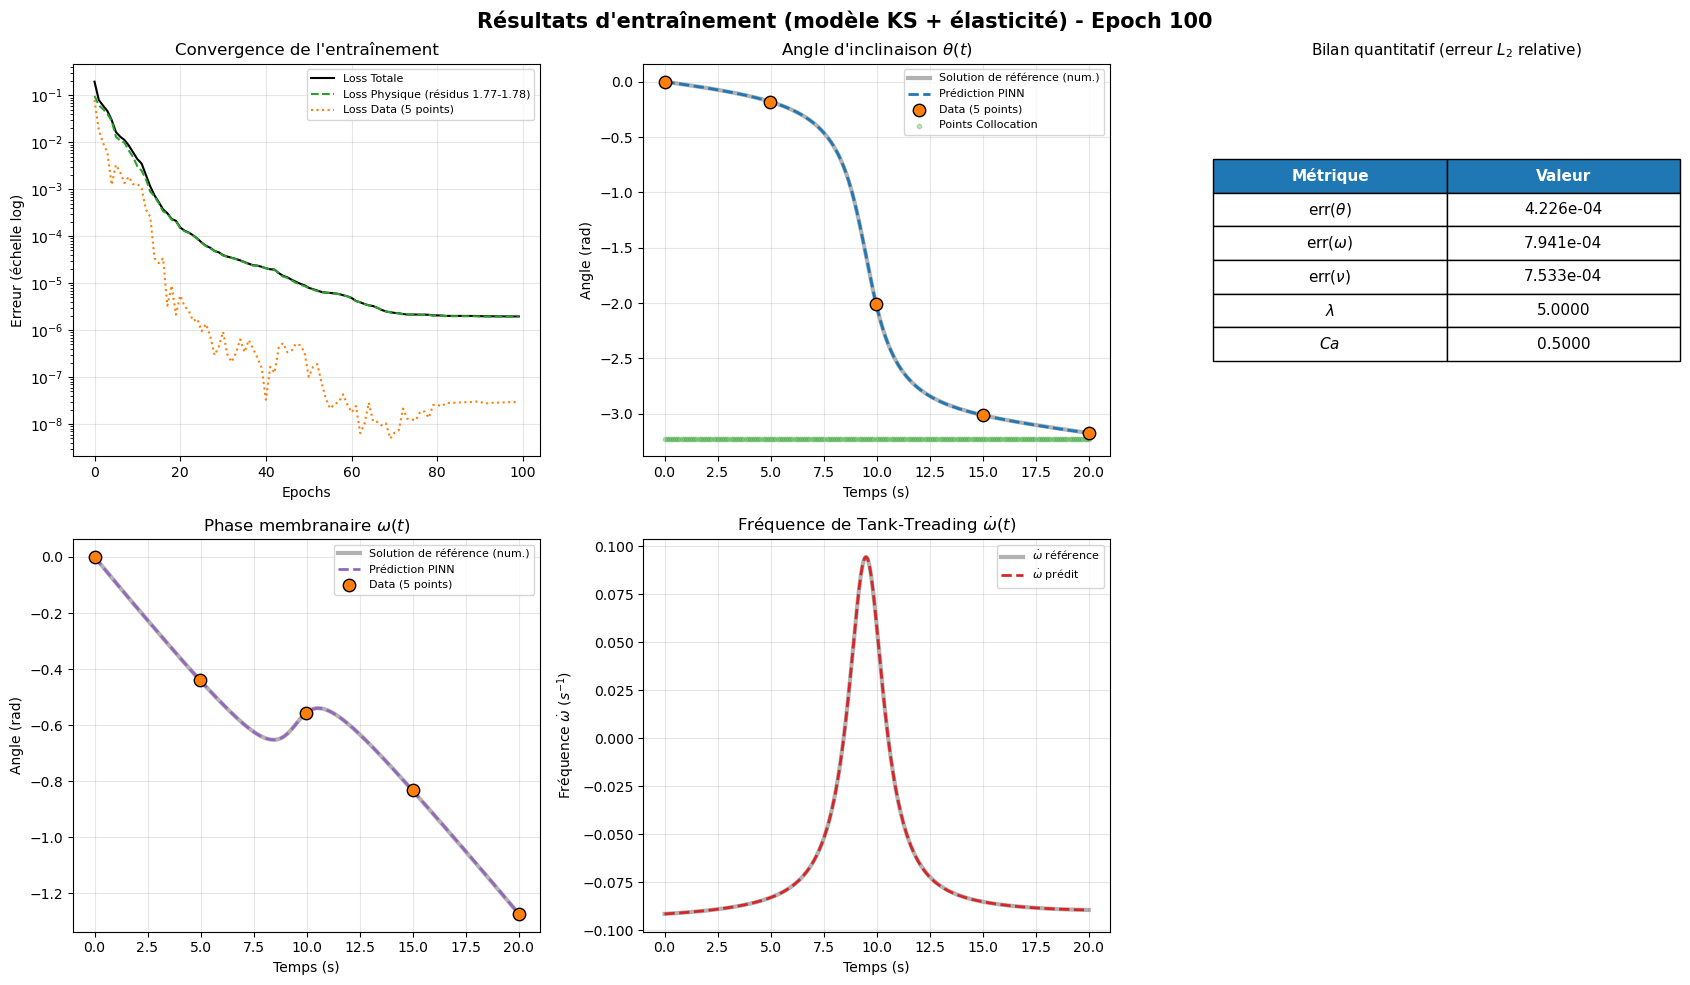

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
Test1bis_mu1.2_lambda1.0            | err_theta = 4.226e-04 | err_omega = 7.941e-04 | err_nu = 7.533e-04


(0.0004226498643845216, 0.0007940817020776079, 0.0007533064034646095)

In [4]:
"""
================================================================================
 PINN — Mouvement d'un globule rouge en cisaillement : modèle de Keller-Skalak
 ÉTENDU avec l'élasticité de cisaillement de la membrane (Abkarian et al. 2007)
 Réf. : Abkarian 2016 (HDR), section 1.3.4, équations (1.77)-(1.78)
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

torch.set_default_dtype(torch.float32)
torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (déplacées ICI, tout en haut, une seule fois)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul (ex: ref oscille autour de 0), on utilise
    l'erreur L2 absolue normalisée par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, filename="metriques_tests.txt"):
    """Calcule les 3 erreurs L2 relatives et les ajoute au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.0
mu_app = 5.0
theta0_val = 0.0

G = 0.5
mu_m = 0.2
Omega_over_V = 7.48e-2
omega0_val = 0.0


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

lam = mu_app / mu
lam_eff = lam * (1 + (mu_m / mu_app) * Omega_over_V)
Ca = G / (mu * kappa)

geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

prefactor = -f3 / (f2 - lam_eff * f1)
elastic_coef = (f1 * G * Omega_over_V) / (2 * f3 * mu * kappa)

print("=== Paramètres Physiques Calculés ===")
print(f"lambda = {lam:.4f}  |  lambda_eff = {lam_eff:.4f}  |  Ca = {Ca:.4f}")
print(f"prefactor (eq. 1.78) = {prefactor:.4f}  |  elastic_coef = {elastic_coef:.4f}")


# =====================================================================
# 2. SOLUTION NUMÉRIQUE DE RÉFÉRENCE + SÉLECTION DES POINTS DATA (5 POINTS)
# =====================================================================
def rhs_reference(t, state):
    theta, omega = state
    domega_dt = kappa * prefactor * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
    dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
    return [dtheta_dt, domega_dt]


t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)

sol_ref = solve_ivp(
    rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
    t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-9, atol=1e-11,
)
theta_ref_np = sol_ref.y[0].reshape(-1, 1)
omega_ref_np = sol_ref.y[1].reshape(-1, 1)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
theta_ref = torch.tensor(theta_ref_np, dtype=torch.float32)
omega_ref = torch.tensor(omega_ref_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
theta_data = theta_ref[data_idx].detach()
omega_data = omega_ref[data_idx].detach()

t_ic = torch.tensor([[0.0]], requires_grad=True)


# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


model = FCN(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    tolerance_grad=1e-7, tolerance_change=1e-9,
    history_size=100, line_search_fn="strong_wolfe",
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, loss_data_hist, epoch_hist = [], [], [], []


# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille passée de 2x2 à 2x3 pour laisser une case au tableau de métriques)
# =====================================================================
def nu_from_theta_omega(theta_arr, omega_arr):
    return kappa * prefactor * (np.cos(2 * theta_arr) - elastic_coef * np.sin(2 * omega_arr))


def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn, omega_pinn = current_model(t_exact)
        theta_pinn = theta_pinn.numpy()
        omega_pinn = omega_pinn.numpy()

    nu_pinn = nu_from_theta_omega(theta_pinn, omega_pinn)
    nu_ref = nu_from_theta_omega(theta_ref_np, omega_ref_np)

    # --- Métriques L2 relatives à l'epoch courante (affichage seulement,
    #     pas d'écriture dans le fichier récapitulatif ici -> ça, c'est
    #     réservé à la métrique finale, section 6, pour ne pas polluer
    #     metriques_tests.txt avec des valeurs intermédiaires) ---
    err_theta = l2_relative_error(theta_pinn, theta_ref_np)
    err_omega = l2_relative_error(omega_pinn, omega_ref_np)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    fig = plt.figure(figsize=(17, 10))
    fig.suptitle(f"Résultats d'entraînement (modèle KS + élasticité) - Epoch {current_epoch}",
                 fontsize=15, fontweight="bold")

    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique (résidus 1.77-1.78)",
              color="tab:green", linestyle="--")
    ax1.plot(epoch_hist, loss_data_hist, label="Loss Data (5 points)",
              color="tab:orange", linestyle=":")
    ax1.set_yscale("log")
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)

    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(t_exact_np, theta_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), theta_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    colloc_y = np.min(theta_ref_np) - 0.05
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")
    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    # --- Tableau des métriques, case libre (position 3, haut-droite) ---
    ax3 = plt.subplot(2, 3, 3)
    ax3.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\omega$)", f"{err_omega:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$\lambda$",     f"{lam:.4f}"],
        [r"$Ca$",          f"{Ca:.4f}"],
    ]
    tbl = ax3.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.5, 0.5],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax3.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(t_exact_np, omega_ref_np, color="grey", linewidth=3, alpha=0.6,
              label="Solution de référence (num.)")
    ax4.plot(t_exact_np, omega_pinn, color="tab:purple", linestyle="--", linewidth=2,
              label="Prédiction PINN")
    ax4.scatter(t_data.numpy(), omega_data.numpy(), color="tab:orange", s=80,
                edgecolors="black", zorder=5, label="Data (5 points)")
    ax4.set_title(r"Phase membranaire $\omega(t)$")
    ax4.set_xlabel("Temps (s)")
    ax4.set_ylabel("Angle (rad)")
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)

    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(t_exact_np, nu_ref, color="grey", linewidth=3, alpha=0.6, label=r"$\dot\omega$ référence")
    ax5.plot(t_exact_np, nu_pinn, color="tab:red", linestyle="--", linewidth=2, label=r"$\dot\omega$ prédit")
    ax5.set_title(r"Fréquence de Tank-Treading $\dot\omega(t)$")
    ax5.set_xlabel("Temps (s)")
    ax5.set_ylabel(r"Fréquence $\dot\omega$ ($s^{-1}$)")
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=8)

    # ax6 (position 6) laissée vide -- grille 2x3 complète sans surcharge

    plt.tight_layout()
    plt.show()          # <-- reste bien à l'intérieur de plot_current_state
    current_model.train()  # <-- reste bien à l'intérieur de plot_current_state


# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [20, 50, 100]

print("\n=== Début de l'entraînement PINN (KS + élasticité, guidé par 5 points, L-BFGS) ===")

for epoch in range(n_epochs):
    loss_tracker = {"total": 0.0, "phys": 0.0, "data": 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred),
            create_graph=True,
        )[0]
        domega_dt = torch.autograd.grad(
            omega_pred, t_physics, grad_outputs=torch.ones_like(omega_pred),
            create_graph=True,
        )[0]

        rhs_omega = kappa * prefactor * (
            torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred)
        )
        residu_omega = domega_dt - rhs_omega

        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta

        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0
        loss.backward()

        loss_tracker["total"] = loss.item()
        loss_tracker["phys"] = loss_physics.item()
        loss_tracker["data"] = loss_data.item()
        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker["total"])
    loss_phys_hist.append(loss_tracker["phys"])
    loss_data_hist.append(loss_tracker["data"])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} "
              f"| Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final, omega_final = model(t_exact)
    theta_final = theta_final.numpy()
    omega_final = omega_final.numpy()
model.train()

nu_final = nu_from_theta_omega(theta_final, omega_final)
nu_ref_final = nu_from_theta_omega(theta_ref_np, omega_ref_np)

print_and_save_metrics(
    "Test1bis_mu1.2_lambda1.0",
    theta_final, theta_ref_np,
    omega_final, omega_ref_np,
    nu_final, nu_ref_final,
)

=== Paramètres Physiques (vraie viscosité cachée) ===
mu_app_TRUE = 1.0  ->  lambda_eff_true = 1.0150  |  prefactor_true = -0.3088
elastic_coef (connu, fixe) = -0.0360
Indices sélectionnés : [  0 124 249 374 499]
Temps t_data sélectionnés : [0.0, 4.969939879759519, 9.97995991983968, 14.98997995991984, 20.0]

=== Début Problème Inverse (L-BFGS, modèle KS + élasticité) ===
Objectif : retrouver mu_app = 1.0
Supposition initiale : mu_app = 5.0000

L-BFGS Epoch    1 | Loss: 1.10e-01 | mu_app = 4.9983
L-BFGS Epoch   10 | Loss: 2.97e-02 | mu_app = 3.9718
L-BFGS Epoch   20 | Loss: 3.32e-03 | mu_app = 1.0789
L-BFGS Epoch   30 | Loss: 1.10e-05 | mu_app = 1.0007
L-BFGS Epoch   40 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch   50 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch   60 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch   70 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch   80 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch   90 | Loss: 6.99e-06 | mu_app = 1.0007
L-BFGS Epoch  100 | Lo

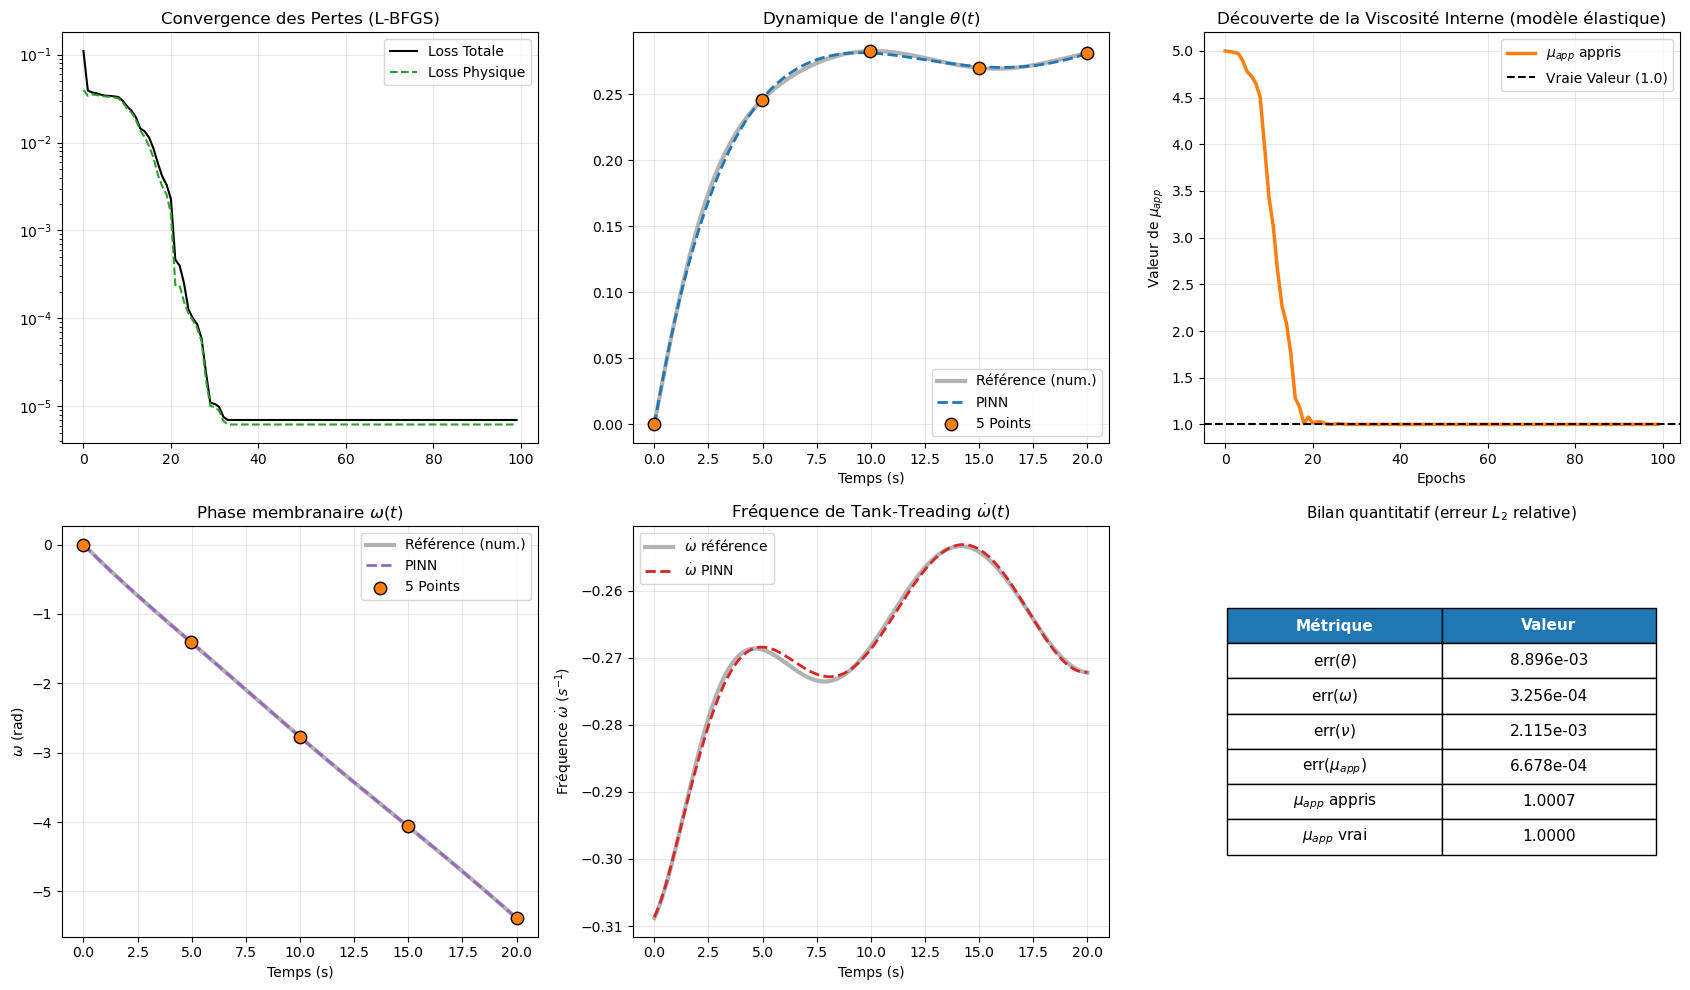

In [7]:
"""
================================================================================
 PINN — PROBLÈME INVERSE : découverte de la viscosité interne mu_app
 Modèle de Keller-Skalak ÉTENDU avec élasticité de membrane (éq. 1.77-1.78)
 Réf. : Abkarian 2016 (HDR), section 1.3.4
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

torch.set_default_dtype(torch.float64)
torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, mu_app_learned=None, mu_app_true=None,
                            filename="metriques_tests.txt"):
    """Calcule les erreurs L2 relatives (theta, omega, nu) + l'erreur relative
    sur mu_app si ces valeurs sont fournies (cas du problème inverse), et
    ajoute une ligne au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    if mu_app_learned is not None and mu_app_true is not None:
        err_mu_app = abs(mu_app_learned - mu_app_true) / abs(mu_app_true)
        line += f" | err_mu_app = {err_mu_app:.3e} (appris={mu_app_learned:.4f}, vrai={mu_app_true:.4f})"

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES (connus, non appris)
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.0
theta0_val = 0.0
omega0_val = 0.0

G = 0.5
mu_m = 0.2
Omega_over_V = 7.48e-2

mu_app_TRUE = 1.0
mu_app_guess = torch.nn.Parameter(torch.tensor([5.0], dtype=torch.float64))


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

elastic_coef = (f1 * G * Omega_over_V) / (2 * f3 * mu * kappa)


def calculate_lambda_eff_and_prefactor(mu_app_val, f1, f2, f3, mu, mu_m, Omega_over_V):
    lam = mu_app_val / mu
    lam_eff = lam * (1 + (mu_m / mu_app_val) * Omega_over_V)
    prefactor = -f3 / (f2 - lam_eff * f1)
    return lam_eff, prefactor


lam_eff_true, prefactor_true = calculate_lambda_eff_and_prefactor(
    mu_app_TRUE, f1, f2, f3, mu, mu_m, Omega_over_V
)

print("=== Paramètres Physiques (vraie viscosité cachée) ===")
print(f"mu_app_TRUE = {mu_app_TRUE}  ->  lambda_eff_true = {lam_eff_true:.4f}  "
      f"|  prefactor_true = {prefactor_true:.4f}")
print(f"elastic_coef (connu, fixe) = {elastic_coef:.4f}")


# =====================================================================
# 2. GÉNÉRATION DE LA SOLUTION DE RÉFÉRENCE + SÉLECTION DES 5 POINTS
# =====================================================================
def rhs_reference(t, state):
    theta, omega = state
    domega_dt = kappa * prefactor_true * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
    dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
    return [dtheta_dt, domega_dt]


t_min, t_max = 0.0, 20.0
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)

sol_ref = solve_ivp(
    rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
    t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-10, atol=1e-12,
)
theta_ref_np = sol_ref.y[0].reshape(-1, 1)
omega_ref_np = sol_ref.y[1].reshape(-1, 1)

t_exact = torch.tensor(t_exact_np, dtype=torch.float64)
theta_ref = torch.tensor(theta_ref_np, dtype=torch.float64)
omega_ref = torch.tensor(omega_ref_np, dtype=torch.float64)

N_total = len(t_exact)
indices_5_points = np.linspace(0, N_total - 1, 5).astype(int)

t_data = t_exact[indices_5_points].detach()
theta_data = theta_ref[indices_5_points].detach()
omega_data = omega_ref[indices_5_points].detach()

print(f"Indices sélectionnés : {indices_5_points}")
print(f"Temps t_data sélectionnés : {t_data.flatten().tolist()}")

t_ic = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True)


# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


model = FCN()

optimizer_lbfgs = torch.optim.LBFGS(
    list(model.parameters()) + [mu_app_guess],
    lr=0.1, max_iter=20,
    tolerance_grad=1e-7, tolerance_change=1e-9,
    history_size=100, line_search_fn="strong_wolfe",
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde, dtype=torch.float64).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []
mu_app_hist = []


# =====================================================================
# 4. BOUCLE D'ENTRAÎNEMENT L-BFGS (PROBLÈME INVERSE)
# =====================================================================
print(f"\n=== Début Problème Inverse (L-BFGS, modèle KS + élasticité) ===")
print(f"Objectif : retrouver mu_app = {mu_app_TRUE}")
print(f"Supposition initiale : mu_app = {mu_app_guess.item():.4f}\n")

epochs_lbfgs = 100
w_phys_final = 1.0

for epoch in range(epochs_lbfgs):
    loss_tracker = {"total": 0.0, "phys": 0.0}

    def closure():
        optimizer_lbfgs.zero_grad()

        _, prefactor_dyn = calculate_lambda_eff_and_prefactor(
            mu_app_guess, f1, f2, f3, mu, mu_m, Omega_over_V
        )

        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred),
            create_graph=True,
        )[0]
        domega_dt = torch.autograd.grad(
            omega_pred, t_physics, grad_outputs=torch.ones_like(omega_pred),
            create_graph=True,
        )[0]

        rhs_omega = kappa * prefactor_dyn * (
            torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred)
        )
        residu_omega = domega_dt - rhs_omega

        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta

        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        loss = loss_data + w_phys_final * loss_physics + loss_x0
        loss.backward()

        loss_tracker["total"] = loss.item()
        loss_tracker["phys"] = loss_physics.item()
        return loss

    optimizer_lbfgs.step(closure)

    loss_total_hist.append(loss_tracker["total"])
    loss_phys_hist.append(loss_tracker["phys"])
    mu_app_hist.append(mu_app_guess.item())
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"L-BFGS Epoch {epoch+1:4d} | Loss: {loss_tracker['total']:.2e} "
              f"| mu_app = {mu_app_guess.item():.4f}")

print(f"\nEntraînement terminé. Valeur trouvée : mu_app = {mu_app_guess.item():.4f} "
      f"(Vraie : {mu_app_TRUE})")


# =====================================================================
# 5. RÉSULTATS, POST-TRAITEMENT ET AFFICHAGE
# =====================================================================
model.eval()
with torch.no_grad():
    theta_pinn, omega_pinn = model(t_exact)
    theta_pinn = theta_pinn.numpy()
    omega_pinn = omega_pinn.numpy()

    _, prefactor_pred = calculate_lambda_eff_and_prefactor(
        mu_app_guess, f1, f2, f3, mu, mu_m, Omega_over_V
    )
    prefactor_pred = prefactor_pred.item()
model.train()

nu_pred = kappa * prefactor_pred * (np.cos(2 * theta_pinn) - elastic_coef * np.sin(2 * omega_pinn))
nu_exact = kappa * prefactor_true * (np.cos(2 * theta_ref_np) - elastic_coef * np.sin(2 * omega_ref_np))


# =====================================================================
# 5bis. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, juste ici)
# =====================================================================
err_theta, err_omega, err_nu = print_and_save_metrics(
    "Test4_EssaiB_mu5to1",
    theta_pinn, theta_ref_np,
    omega_pinn, omega_ref_np,
    nu_pred, nu_exact,
    mu_app_learned=mu_app_guess.item(),
    mu_app_true=mu_app_TRUE,
)

mu_app_learned_val = mu_app_guess.item()
err_mu_app = abs(mu_app_learned_val - mu_app_TRUE) / abs(mu_app_TRUE)

# =====================================================================
# 6. FIGURES (inchangé, toujours après les métriques)
# =====================================================================
fig = plt.figure(figsize=(17, 10))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
ax1.set_yscale("log")
ax1.set_title("Convergence des Pertes (L-BFGS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(2, 3, 2)
ax2.plot(t_exact_np, theta_ref_np, color="grey", linewidth=3, alpha=0.6, label="Référence (num.)")
ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="PINN")
ax2.scatter(t_data.numpy(), theta_data.numpy(), color="tab:orange", s=80,
            edgecolors="k", zorder=5, label="5 Points")
ax2.set_title(r"Dynamique de l'angle $\theta(t)$")
ax2.set_xlabel("Temps (s)")
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = plt.subplot(2, 3, 3)
ax3.plot(epoch_hist, mu_app_hist, color="tab:orange", linewidth=2.5, label=r"$\mu_{app}$ appris")
ax3.axhline(y=mu_app_TRUE, color="k", linestyle="--", label=f"Vraie Valeur ({mu_app_TRUE})")
ax3.set_title("Découverte de la Viscosité Interne (modèle élastique)")
ax3.set_xlabel("Epochs")
ax3.set_ylabel(r"Valeur de $\mu_{app}$")
ax3.grid(True, alpha=0.3)
ax3.legend()

ax4 = plt.subplot(2, 3, 4)
ax4.plot(t_exact_np, omega_ref_np, color="grey", linewidth=3, alpha=0.6, label="Référence (num.)")
ax4.plot(t_exact_np, omega_pinn, color="tab:purple", linestyle="--", linewidth=2, label="PINN")
ax4.scatter(t_data.numpy(), omega_data.numpy(), color="tab:orange", s=80,
            edgecolors="k", zorder=5, label="5 Points")
ax4.set_title(r"Phase membranaire $\omega(t)$")
ax4.set_xlabel("Temps (s)")
ax4.set_ylabel(r"$\omega$ (rad)")
ax4.grid(True, alpha=0.3)
ax4.legend()

ax5 = plt.subplot(2, 3, 5)
ax5.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label=r"$\dot\omega$ référence")
ax5.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label=r"$\dot\omega$ PINN")
ax5.set_title(r"Fréquence de Tank-Treading $\dot\omega(t)$")
ax5.set_xlabel("Temps (s)")
ax5.set_ylabel(r"Fréquence $\dot\omega$ ($s^{-1}$)")
ax5.grid(True, alpha=0.3)
ax5.legend()
# --- Tableau des métriques L2, dans la case libre (position 6) ---
ax6 = plt.subplot(2, 3, 6)
ax6.axis("off")  # pas d'axes, seulement le tableau

table_data = [
    [r"err($\theta$)",      f"{err_theta:.3e}"],
    [r"err($\omega$)",      f"{err_omega:.3e}"],
    [r"err($\nu$)",         f"{err_nu:.3e}"],
    [r"err($\mu_{app}$)",   f"{err_mu_app:.3e}"],
    [r"$\mu_{app}$ appris", f"{mu_app_learned_val:.4f}"],
    [r"$\mu_{app}$ vrai",   f"{mu_app_TRUE:.4f}"],
]

tbl = ax6.table(
    cellText=table_data,
    colLabels=["Métrique", "Valeur"],
    cellLoc="center",
    loc="center",
    colWidths=[0.45, 0.45],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)  # agrandit un peu la hauteur des lignes

# En-tête en gras / couleur pour bien la distinguer
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", color="white")
        cell.set_facecolor("tab:blue")

ax6.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

plt.tight_layout()
plt.savefig("pinn_inverse_result_mu1.png", dpi=150)
print("Figure sauvegardee : pinn_inverse_result_mu1.png")
plt.show()

=== Paramètres Physiques (vraie viscosité cachée) ===
mu_app_TRUE = 5.0  ->  lambda_eff_true = 4.1791  |  prefactor_true = -0.1072
elastic_coef (connu, fixe) = -0.0300
Indices sélectionnés : [  0 124 249 374 499]
Temps t_data sélectionnés : [0.0, 4.969939879759519, 9.97995991983968, 14.98997995991984, 20.0]

=== Début Problème Inverse (L-BFGS, modèle KS + élasticité) ===
Objectif : retrouver mu_app = 5.0
Supposition initiale : mu_app = 1.0000

L-BFGS Epoch    1 | Loss: 4.10e-01 | mu_app = 1.0375
L-BFGS Epoch   10 | Loss: 2.85e-03 | mu_app = 3.7930
L-BFGS Epoch   20 | Loss: 3.07e-05 | mu_app = 5.0884
L-BFGS Epoch   30 | Loss: 7.17e-06 | mu_app = 4.9951
L-BFGS Epoch   40 | Loss: 3.69e-06 | mu_app = 5.0014
L-BFGS Epoch   50 | Loss: 3.69e-06 | mu_app = 5.0016
L-BFGS Epoch   60 | Loss: 3.69e-06 | mu_app = 5.0016
L-BFGS Epoch   70 | Loss: 3.69e-06 | mu_app = 5.0016
L-BFGS Epoch   80 | Loss: 3.69e-06 | mu_app = 5.0016
L-BFGS Epoch   90 | Loss: 3.69e-06 | mu_app = 5.0016
L-BFGS Epoch  100 | Lo

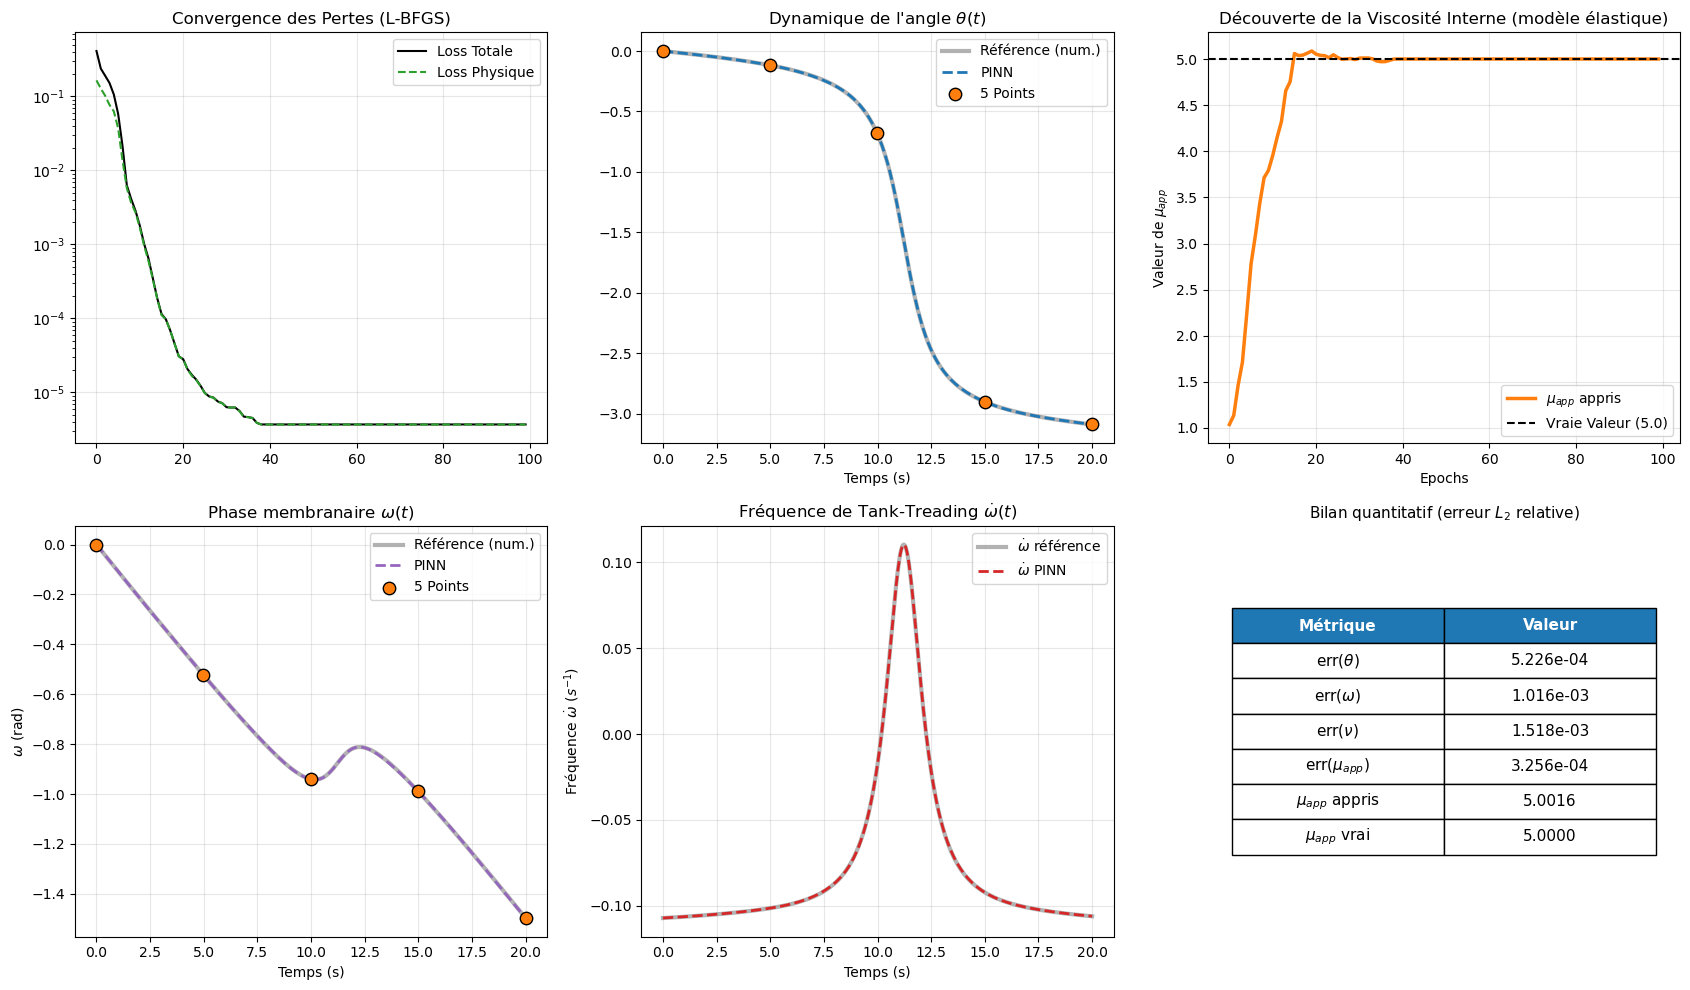

In [8]:
"""
================================================================================
 PINN — PROBLÈME INVERSE : découverte de la viscosité interne mu_app
 Modèle de Keller-Skalak ÉTENDU avec élasticité de membrane (éq. 1.77-1.78)
 Réf. : Abkarian 2016 (HDR), section 1.3.4
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

torch.set_default_dtype(torch.float64)
torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, mu_app_learned=None, mu_app_true=None,
                            filename="metriques_tests.txt"):
    """Calcule les erreurs L2 relatives (theta, omega, nu) + l'erreur relative
    sur mu_app si ces valeurs sont fournies (cas du problème inverse), et
    ajoute une ligne au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    if mu_app_learned is not None and mu_app_true is not None:
        err_mu_app = abs(mu_app_learned - mu_app_true) / abs(mu_app_true)
        line += f" | err_mu_app = {err_mu_app:.3e} (appris={mu_app_learned:.4f}, vrai={mu_app_true:.4f})"

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES (connus, non appris)
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.2
theta0_val = 0.0
omega0_val = 0.0

G = 0.5
mu_m = 0.2
Omega_over_V = 7.48e-2

mu_app_TRUE = 5.0
mu_app_guess = torch.nn.Parameter(torch.tensor([1.0], dtype=torch.float64))


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

elastic_coef = (f1 * G * Omega_over_V) / (2 * f3 * mu * kappa)


def calculate_lambda_eff_and_prefactor(mu_app_val, f1, f2, f3, mu, mu_m, Omega_over_V):
    lam = mu_app_val / mu
    lam_eff = lam * (1 + (mu_m / mu_app_val) * Omega_over_V)
    prefactor = -f3 / (f2 - lam_eff * f1)
    return lam_eff, prefactor


lam_eff_true, prefactor_true = calculate_lambda_eff_and_prefactor(
    mu_app_TRUE, f1, f2, f3, mu, mu_m, Omega_over_V
)

print("=== Paramètres Physiques (vraie viscosité cachée) ===")
print(f"mu_app_TRUE = {mu_app_TRUE}  ->  lambda_eff_true = {lam_eff_true:.4f}  "
      f"|  prefactor_true = {prefactor_true:.4f}")
print(f"elastic_coef (connu, fixe) = {elastic_coef:.4f}")


# =====================================================================
# 2. GÉNÉRATION DE LA SOLUTION DE RÉFÉRENCE + SÉLECTION DES 5 POINTS
# =====================================================================
def rhs_reference(t, state):
    theta, omega = state
    domega_dt = kappa * prefactor_true * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
    dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
    return [dtheta_dt, domega_dt]


t_min, t_max = 0.0, 20.0
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)

sol_ref = solve_ivp(
    rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
    t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-10, atol=1e-12,
)
theta_ref_np = sol_ref.y[0].reshape(-1, 1)
omega_ref_np = sol_ref.y[1].reshape(-1, 1)

t_exact = torch.tensor(t_exact_np, dtype=torch.float64)
theta_ref = torch.tensor(theta_ref_np, dtype=torch.float64)
omega_ref = torch.tensor(omega_ref_np, dtype=torch.float64)

N_total = len(t_exact)
indices_5_points = np.linspace(0, N_total - 1, 5).astype(int)

t_data = t_exact[indices_5_points].detach()
theta_data = theta_ref[indices_5_points].detach()
omega_data = omega_ref[indices_5_points].detach()

print(f"Indices sélectionnés : {indices_5_points}")
print(f"Temps t_data sélectionnés : {t_data.flatten().tolist()}")

t_ic = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True)


# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


model = FCN()

optimizer_lbfgs = torch.optim.LBFGS(
    list(model.parameters()) + [mu_app_guess],
    lr=0.1, max_iter=20,
    tolerance_grad=1e-7, tolerance_change=1e-9,
    history_size=100, line_search_fn="strong_wolfe",
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde, dtype=torch.float64).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []
mu_app_hist = []


# =====================================================================
# 4. BOUCLE D'ENTRAÎNEMENT L-BFGS (PROBLÈME INVERSE)
# =====================================================================
print(f"\n=== Début Problème Inverse (L-BFGS, modèle KS + élasticité) ===")
print(f"Objectif : retrouver mu_app = {mu_app_TRUE}")
print(f"Supposition initiale : mu_app = {mu_app_guess.item():.4f}\n")

epochs_lbfgs = 100
w_phys_final = 1.0

for epoch in range(epochs_lbfgs):
    loss_tracker = {"total": 0.0, "phys": 0.0}

    def closure():
        optimizer_lbfgs.zero_grad()

        _, prefactor_dyn = calculate_lambda_eff_and_prefactor(
            mu_app_guess, f1, f2, f3, mu, mu_m, Omega_over_V
        )

        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred),
            create_graph=True,
        )[0]
        domega_dt = torch.autograd.grad(
            omega_pred, t_physics, grad_outputs=torch.ones_like(omega_pred),
            create_graph=True,
        )[0]

        rhs_omega = kappa * prefactor_dyn * (
            torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred)
        )
        residu_omega = domega_dt - rhs_omega

        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta

        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        loss = loss_data + w_phys_final * loss_physics + loss_x0
        loss.backward()

        loss_tracker["total"] = loss.item()
        loss_tracker["phys"] = loss_physics.item()
        return loss

    optimizer_lbfgs.step(closure)

    loss_total_hist.append(loss_tracker["total"])
    loss_phys_hist.append(loss_tracker["phys"])
    mu_app_hist.append(mu_app_guess.item())
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"L-BFGS Epoch {epoch+1:4d} | Loss: {loss_tracker['total']:.2e} "
              f"| mu_app = {mu_app_guess.item():.4f}")

print(f"\nEntraînement terminé. Valeur trouvée : mu_app = {mu_app_guess.item():.4f} "
      f"(Vraie : {mu_app_TRUE})")


# =====================================================================
# 5. RÉSULTATS, POST-TRAITEMENT ET AFFICHAGE
# =====================================================================
model.eval()
with torch.no_grad():
    theta_pinn, omega_pinn = model(t_exact)
    theta_pinn = theta_pinn.numpy()
    omega_pinn = omega_pinn.numpy()

    _, prefactor_pred = calculate_lambda_eff_and_prefactor(
        mu_app_guess, f1, f2, f3, mu, mu_m, Omega_over_V
    )
    prefactor_pred = prefactor_pred.item()
model.train()

nu_pred = kappa * prefactor_pred * (np.cos(2 * theta_pinn) - elastic_coef * np.sin(2 * omega_pinn))
nu_exact = kappa * prefactor_true * (np.cos(2 * theta_ref_np) - elastic_coef * np.sin(2 * omega_ref_np))


# =====================================================================
# 5bis. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, juste ici)
# =====================================================================
err_theta, err_omega, err_nu = print_and_save_metrics(
    "Test4_EssaiA_mu1to5",
    theta_pinn, theta_ref_np,
    omega_pinn, omega_ref_np,
    nu_pred, nu_exact,
    mu_app_learned=mu_app_guess.item(),
    mu_app_true=mu_app_TRUE,
)

mu_app_learned_val = mu_app_guess.item()
err_mu_app = abs(mu_app_learned_val - mu_app_TRUE) / abs(mu_app_TRUE)

# =====================================================================
# 6. FIGURES (inchangé, toujours après les métriques)
# =====================================================================
fig = plt.figure(figsize=(17, 10))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
ax1.set_yscale("log")
ax1.set_title("Convergence des Pertes (L-BFGS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(2, 3, 2)
ax2.plot(t_exact_np, theta_ref_np, color="grey", linewidth=3, alpha=0.6, label="Référence (num.)")
ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="PINN")
ax2.scatter(t_data.numpy(), theta_data.numpy(), color="tab:orange", s=80,
            edgecolors="k", zorder=5, label="5 Points")
ax2.set_title(r"Dynamique de l'angle $\theta(t)$")
ax2.set_xlabel("Temps (s)")
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = plt.subplot(2, 3, 3)
ax3.plot(epoch_hist, mu_app_hist, color="tab:orange", linewidth=2.5, label=r"$\mu_{app}$ appris")
ax3.axhline(y=mu_app_TRUE, color="k", linestyle="--", label=f"Vraie Valeur ({mu_app_TRUE})")
ax3.set_title("Découverte de la Viscosité Interne (modèle élastique)")
ax3.set_xlabel("Epochs")
ax3.set_ylabel(r"Valeur de $\mu_{app}$")
ax3.grid(True, alpha=0.3)
ax3.legend()


ax4 = plt.subplot(2, 3, 4)
ax4.plot(t_exact_np, omega_ref_np, color="grey", linewidth=3, alpha=0.6, label="Référence (num.)")
ax4.plot(t_exact_np, omega_pinn, color="tab:purple", linestyle="--", linewidth=2, label="PINN")
ax4.scatter(t_data.numpy(), omega_data.numpy(), color="tab:orange", s=80,
            edgecolors="k", zorder=5, label="5 Points")
ax4.set_title(r"Phase membranaire $\omega(t)$")
ax4.set_xlabel("Temps (s)")
ax4.set_ylabel(r"$\omega$ (rad)")
ax4.grid(True, alpha=0.3)
ax4.legend()

ax5 = plt.subplot(2, 3, 5)
ax5.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label=r"$\dot\omega$ référence")
ax5.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label=r"$\dot\omega$ PINN")
ax5.set_title(r"Fréquence de Tank-Treading $\dot\omega(t)$")
ax5.set_xlabel("Temps (s)")
ax5.set_ylabel(r"Fréquence $\dot\omega$ ($s^{-1}$)")
ax5.grid(True, alpha=0.3)
ax5.legend()
# --- Tableau des métriques L2, dans la case libre (position 6) ---
ax6 = plt.subplot(2, 3, 6)
ax6.axis("off")  # pas d'axes, seulement le tableau

table_data = [
    [r"err($\theta$)",      f"{err_theta:.3e}"],
    [r"err($\omega$)",      f"{err_omega:.3e}"],
    [r"err($\nu$)",         f"{err_nu:.3e}"],
    [r"err($\mu_{app}$)",   f"{err_mu_app:.3e}"],
    [r"$\mu_{app}$ appris", f"{mu_app_learned_val:.4f}"],
    [r"$\mu_{app}$ vrai",   f"{mu_app_TRUE:.4f}"],
]

tbl = ax6.table(
    cellText=table_data,
    colLabels=["Métrique", "Valeur"],
    cellLoc="center",
    loc="center",
    colWidths=[0.45, 0.45],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)  # agrandit un peu la hauteur des lignes

# En-tête en gras / couleur pour bien la distinguer
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", color="white")
        cell.set_facecolor("tab:blue")

ax6.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

plt.tight_layout()
plt.savefig("pinn_inverse_result_mu5.png", dpi=150)
print("Figure sauvegardee : pinn_inverse_result_mu5.png")
plt.show()

=== Balayage de Ca (lambda = 1.0 fixé) ===
Ca=0.020 (G=0.020)  ->  entraînement terminé.
Ca=0.050 (G=0.050)  ->  entraînement terminé.
Ca=0.000 (G=0.000)  ->  entraînement terminé.
Ca=0.200 (G=0.200)  ->  entraînement terminé.
Ca=0.500 (G=0.500)  ->  entraînement terminé.
Ca=1.000 (G=1.000)  ->  entraînement terminé.
Ca=2.000 (G=2.000)  ->  entraînement terminé.
Ca=5.000 (G=5.000)  ->  entraînement terminé.

=== Métriques quantitatives (erreur L2 relative), une ligne par Ca ===
Test3_Ca0.02                        | err_theta = 1.199e-03 | err_omega = 8.088e-05 | err_nu = 2.771e-04
Test3_Ca0.05                        | err_theta = 1.643e-03 | err_omega = 5.463e-04 | err_nu = 4.672e-04
Test3_Ca0.00                        | err_theta = 2.168e-03 | err_omega = 3.372e-04 | err_nu = 6.361e-04
Test3_Ca0.20                        | err_theta = 4.517e-03 | err_omega = 2.969e-04 | err_nu = 1.210e-03
Test3_Ca0.50                        | err_theta = 4.963e-03 | err_omega = 5.619e-04 | err_nu = 1.

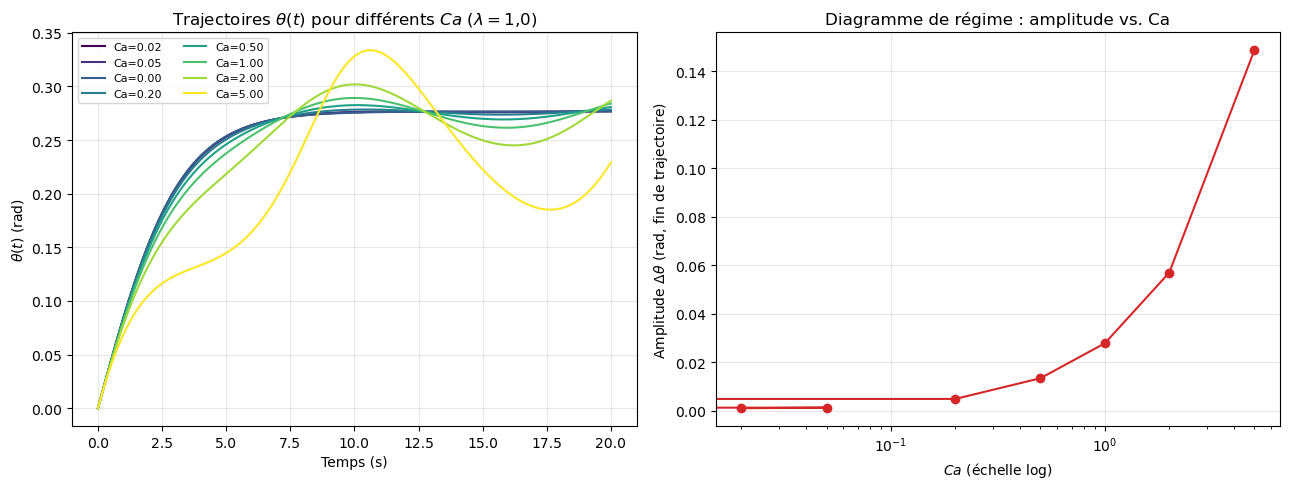


Résumé :
  Ca=0.020  ->  Delta_theta(fin) = 0.0010 rad
  Ca=0.050  ->  Delta_theta(fin) = 0.0012 rad
  Ca=0.000  ->  Delta_theta(fin) = 0.0011 rad
  Ca=0.200  ->  Delta_theta(fin) = 0.0048 rad
  Ca=0.500  ->  Delta_theta(fin) = 0.0133 rad
  Ca=1.000  ->  Delta_theta(fin) = 0.0278 rad
  Ca=2.000  ->  Delta_theta(fin) = 0.0569 rad
  Ca=5.000  ->  Delta_theta(fin) = 0.1486 rad


In [9]:
"""
================================================================================
 Test 3 — Balayage du nombre capillaire Ca = G / (mu_o * gamma_dot)
 Modèle KS étendu avec élasticité (Abkarian et al. 2007), équations (1.77)-(1.78)
================================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

# Reset explicite : ce script travaille en float32, indépendamment de ce qui a été
# exécuté avant dans le même kernel (ex : le script du problème inverse utilise
# torch.set_default_dtype(torch.float64), qui reste actif tant que le kernel tourne
# et provoque un RuntimeError "mat1 and mat2 must have the same dtype" sinon).
torch.set_default_dtype(torch.float32)

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics(test_name, theta_pinn, theta_ref, omega_pinn, omega_ref,
                            nu_pinn, nu_ref, mu_app_learned=None, mu_app_true=None,
                            filename="metriques_tests.txt"):
    """Calcule les erreurs L2 relatives (theta, omega, nu) et ajoute une ligne
    au fichier récapitulatif commun à tous les tests."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_omega = l2_relative_error(omega_pinn, omega_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_omega = {err_omega:.3e} | "
            f"err_nu = {err_nu:.3e}")

    if mu_app_learned is not None and mu_app_true is not None:
        err_mu_app = abs(mu_app_learned - mu_app_true) / abs(mu_app_true)
        line += f" | err_mu_app = {err_mu_app:.3e} (appris={mu_app_learned:.4f}, vrai={mu_app_true:.4f})"

    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_omega, err_nu


# =====================================================================
# 1. PARAMÈTRES FIXES (identiques aux Tests 1 et 2)
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.0
mu_m = 0.2
Omega_over_V = 7.48e-2
theta0_val = 0.0
omega0_val = 0.0

lam = 1.0                 # <-- FIXÉ : cellule saine (cas du Test 2)
mu_app = lam * mu

# --- Balayage : on fait varier G, donc Ca = G / (mu * kappa) ---
G_values = np.array([0.02, 0.05, 0.0, 0.2, 0.5, 1.0, 2.0, 5.0])
Ca_values = G_values / (mu * kappa)


def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3) ** (1 / 3)
    alpha1, alpha2, alpha3 = a1 / a0, a2 / a0, a3 / a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1 / r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)
    f1 = (r2 - (1 / r2)) ** 2
    f2 = 4 * (z1**2) * (1 - 2 / z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2


f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)
geo1 = 2 * a1 * a2 / (a1**2 + a2**2)
geo2 = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

t_min, t_max = 0.0, 20.0
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)


class FCN(nn.Module):
    """Identique aux Tests 1 et 2 : 1 entrée (t) -> 2 sorties (theta, omega)."""

    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        out = self.fce(x)
        return out[:, 0:1], out[:, 1:2]


def run_one_Ca(G_val, n_epochs=100, N_pde=200, N_data=5, verbose=True):
    """Entraîne un PINN complet (L-BFGS + 5 points uniformes) pour une valeur de G
    donnée, et renvoie les trajectoires theta/omega/nu prédites et de référence."""

    lam_eff = lam * (1 + (mu_m / mu_app) * Omega_over_V)   # ne dépend pas de G
    prefactor = -f3 / (f2 - lam_eff * f1)
    elastic_coef = (f1 * G_val * Omega_over_V) / (2 * f3 * mu * kappa)
    Ca = G_val / (mu * kappa)

    def nu_from_theta_omega(theta_arr, omega_arr):
        """Reconstruit nu = omega_dot/gamma_dot via la formule fermée (1.78),
        avec le prefactor/elastic_coef propres à CE G_val."""
        return kappa * prefactor * (np.cos(2 * theta_arr) - elastic_coef * np.sin(2 * omega_arr))

    # --- Solution de référence (RK45) ---
    def rhs_reference(t, state):
        theta, omega = state
        domega_dt = kappa * prefactor * (np.cos(2 * theta) - elastic_coef * np.sin(2 * omega))
        dtheta_dt = kappa * (-0.5 + geo2 * np.cos(2 * theta)) - geo1 * domega_dt
        return [dtheta_dt, domega_dt]

    sol_ref = solve_ivp(
        rhs_reference, [t_min, t_max], [theta0_val, omega0_val],
        t_eval=t_exact_np.flatten(), method="RK45", rtol=1e-9, atol=1e-11,
    )
    theta_ref_np = sol_ref.y[0].reshape(-1, 1)
    omega_ref_np = sol_ref.y[1].reshape(-1, 1)

    t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
    theta_ref = torch.tensor(theta_ref_np, dtype=torch.float32)
    omega_ref = torch.tensor(omega_ref_np, dtype=torch.float32)

    data_idx = np.linspace(0, len(t_exact_np) - 1, N_data).astype(int)
    t_data = t_exact[data_idx].detach()
    theta_data = theta_ref[data_idx].detach()
    omega_data = omega_ref[data_idx].detach()
    t_ic = torch.tensor([[0.0]], requires_grad=True)
    t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

    model = FCN()
    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=0.1, max_iter=20,
        tolerance_grad=1e-7, tolerance_change=1e-9,
        history_size=100, line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        theta_pred, omega_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(theta_pred, t_physics,
                                         grad_outputs=torch.ones_like(theta_pred),
                                         create_graph=True)[0]
        domega_dt = torch.autograd.grad(omega_pred, t_physics,
                                         grad_outputs=torch.ones_like(omega_pred),
                                         create_graph=True)[0]
        rhs_omega = kappa * prefactor * (torch.cos(2 * theta_pred) - elastic_coef * torch.sin(2 * omega_pred))
        residu_omega = domega_dt - rhs_omega
        rhs_theta = kappa * (-0.5 + geo2 * torch.cos(2 * theta_pred)) - geo1 * domega_dt
        residu_theta = dtheta_dt - rhs_theta
        loss_physics = torch.mean(residu_theta**2) + torch.mean(residu_omega**2)

        theta_0_pred, omega_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val) ** 2) + \
                  torch.mean((omega_0_pred - omega0_val) ** 2)

        theta_data_pred, omega_data_pred = model(t_data)
        loss_data = torch.mean((theta_data_pred - theta_data) ** 2) + \
                    torch.mean((omega_data_pred - omega_data) ** 2)

        loss = loss_data + loss_physics + loss_x0
        loss.backward()
        return loss

    for epoch in range(n_epochs):
        optimizer.step(closure)

    model.eval()
    with torch.no_grad():
        theta_pinn, omega_pinn = model(t_exact)
        theta_pinn = theta_pinn.numpy()
        omega_pinn = omega_pinn.numpy()
    model.train()

    nu_pinn = nu_from_theta_omega(theta_pinn, omega_pinn)
    nu_ref = nu_from_theta_omega(theta_ref_np, omega_ref_np)

    if verbose:
        print(f"Ca={Ca:.3f} (G={G_val:.3f})  ->  entraînement terminé.")

    return {
        "Ca": Ca, "G": G_val,
        "t": t_exact_np.flatten(),
        "theta_pinn": theta_pinn.flatten(),
        "omega_pinn": omega_pinn.flatten(),
        "theta_ref": theta_ref_np.flatten(),
        "omega_ref": omega_ref_np.flatten(),
        "nu_pinn": nu_pinn.flatten(),
        "nu_ref": nu_ref.flatten(),
    }


# =====================================================================
# 2. BOUCLE SUR LES VALEURS DE Ca
# =====================================================================
results = []
print("=== Balayage de Ca (lambda = 1.0 fixé) ===")
for G_val in G_values:
    results.append(run_one_Ca(G_val))


# =====================================================================
# 2bis. MÉTRIQUES FINALES (une ligne par valeur de Ca, appelées ICI, une seule fois)
# =====================================================================
print("\n=== Métriques quantitatives (erreur L2 relative), une ligne par Ca ===")
for r in results:
    print_and_save_metrics(
        f"Test3_Ca{r['Ca']:.2f}",
        r["theta_pinn"], r["theta_ref"],
        r["omega_pinn"], r["omega_ref"],
        r["nu_pinn"], r["nu_ref"],
    )


# =====================================================================
# 3. INDICATEUR DE RÉGIME : amplitude d'oscillation de theta en fin de trajectoire
# =====================================================================
burn_in_frac = 0.5  # on ignore la première moitié (transitoire de convergence vers le régime établi)
delta_theta = []
for r in results:
    n = len(r["t"])
    theta_tail = r["theta_ref"][int(burn_in_frac * n):]
    delta_theta.append(np.max(theta_tail) - np.min(theta_tail))
delta_theta = np.array(delta_theta)

# =====================================================================
# 4. FIGURE DE SYNTHÈSE
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Trajectoires theta(t) superposées, colormap selon Ca
cmap = plt.cm.viridis
for i, r in enumerate(results):
    color = cmap(i / (len(results) - 1))
    axes[0].plot(r["t"], r["theta_ref"], color=color, label=f"Ca={r['Ca']:.2f}")
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel(r"$\theta(t)$ (rad)")
axes[0].set_title(r"Trajectoires $\theta(t)$ pour différents $Ca$ ($\lambda=1{,}0$)")
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# (b) Amplitude d'oscillation en fonction de Ca
axes[1].plot(Ca_values, delta_theta, "o-", color="tab:red")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$Ca$ (échelle log)")
axes[1].set_ylabel(r"Amplitude $\Delta\theta$ (rad, fin de trajectoire)")
axes[1].set_title("Diagramme de régime : amplitude vs. Ca")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("test3_balayage_Ca.png", dpi=150)
plt.show()

print("\nRésumé :")
for r, dth in zip(results, delta_theta):
    print(f"  Ca={r['Ca']:.3f}  ->  Delta_theta(fin) = {dth:.4f} rad")